In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
#mpl.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import seaborn as sns
sns.set_style("white")
sns.set_style("ticks") 
from scipy.stats import sem
from scipy.stats import tstd
from sklearn.preprocessing import minmax_scale

import matlab.engine
eng = matlab.engine.start_matlab()

from sklearn.linear_model import LinearRegression
import json

In [2]:
def extract_frameTimes_from_metadata(metadata_filename):
    frameTimes = []
    with open(metadata_filename, "r") as metadata:
        for line in metadata:
            pieces = line.split(":")
            if len(pieces) < 2:
                continue
            else:
                if eval(pieces[0].strip()) == "Time":
                    hour = int(pieces[1].split()[-1])
                    #print(hour
                    minute = int(pieces[2])
                    #print(minute
                    second = int(pieces[3].split()[0])
                    #print(second
                    ms = int(pieces[3].split('-')[1].strip().strip(',').strip('"'))
                    #print(ms
                    converted_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)+ms
                    #print(converted_time
                    frameTimes.append(converted_time)
    metadata.close()
    return frameTimes

def extract_temps_times_from_metadata(stim_filename):
    Stim_data = {}
    Stim_data['Temp'] = []
    Stim_data['Time'] = []
    with open(stim_filename, "r") as stim:
        if '/' in stim_filename:
            stim_filename = stim_filename.split('/')[-1]
            
        rep_to_time = stim_filename.split(".txt")[0].split("_")
        hour = int(rep_to_time[1][0]+rep_to_time[1][1])
        minute = int(rep_to_time[1][2]+rep_to_time[1][3])
        #second = int(rep_to_time[1][4]+rep_to_time[1][5])
        #ms = int(rep_to_time[2])
        #starting_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)+ms
        hour_min = (hour*60*60*1000)+(minute*60*1000)

        elapsed_time_check = 0
        elapsed_min = 0
        for line in stim:
            #print(line
            pieces = line.split("\t")
            if len(pieces) < 2 or len(pieces) > 4:
                continue
            else:
                Stim_data['Temp'].append(float(pieces[0]))

                sec = int(pieces[3].split(".")[0])
                ms = int(pieces[3].split(".")[1])
                elapsed_time = (elapsed_min*60*1000)+(sec*1000)+ms
                
                if (hour_min+elapsed_time) >= 86400000:
                    midnight_crossing = hour_min+elapsed_time
                    elapsed_time = midnight_crossing - 86400000
                    elapsed_time_check = -1
                    hour_min = 0
                    elapsed_min = 0

                if elapsed_time > elapsed_time_check:
                    Stim_data['Time'].append(hour_min+elapsed_time)
                    elapsed_time_check = elapsed_time
                elif elapsed_time <= elapsed_time_check:
                    elapsed_min += 1
                    elapsed_time = (elapsed_min*60*1000)+(sec*1000)+ms
                    Stim_data['Time'].append(hour_min+elapsed_time)
                    elapsed_time_check = elapsed_time
                else:
                    print('issue, something wrong')
    stim.close()
    return Stim_data

def align_Ca_to_stim(GCaMP_array, RFP_array, frameTimes, Stim):
    Stim_aligned_data = {}
    Stim_aligned_data['GCaMP'] = np.zeros((len(GCaMP_array),len(Stim['Time'])))
    Stim_aligned_data['RFP'] = np.zeros((len(RFP_array),len(Stim['Time'])))
    Stim_aligned_data['Time'] = []
    Stim_aligned_data['Temp'] = Stim['Temp']
    check = 1
    midnight_checker = 0
    for i in range(len(Stim['Time'])):
        if Stim['Time'][i-1] > 86340000 and Stim['Time'][i] < 60000 and midnight_checker == 0:
            Stim_aligned_data['Time'].append(Stim['Time'][i]+(86400000-Stim['Time'][0]))
            midnight_checker = 1
        elif midnight_checker == 1: 
            Stim_aligned_data['Time'].append(Stim['Time'][i]+(86400000-Stim['Time'][0]))
        else:
            Stim_aligned_data['Time'].append(Stim['Time'][i]-Stim['Time'][0])
        if Stim['Time'][i] > max(frameTimes):
            for j in range(len(GCaMP_array)):
                Stim_aligned_data['GCaMP'][j,i] = GCaMP_array[j,(len(GCaMP_array[j,:])-1)]
                Stim_aligned_data['RFP'][j,i] = RFP_array[j,(len(RFP_array[j,:])-1)]
            print('missed end')
        elif Stim['Time'][i] < min(frameTimes):
            for j in range(len(GCaMP_array)):
                Stim_aligned_data['GCaMP'][j,i] = GCaMP_array[j,0]
                Stim_aligned_data['RFP'][j,i] = RFP_array[j,0]
            print('missed start')
        else:
            for j in range(check, len(frameTimes)):
                if frameTimes[j-1] < Stim['Time'][i] <= frameTimes[j]:
                    for k in range(len(GCaMP_array)):
                        Stim_aligned_data['GCaMP'][k,i] = GCaMP_array[k,j]
                        Stim_aligned_data['RFP'][k,i] = RFP_array[k,j]
                    check = j
                    break
    return Stim_aligned_data

def ratio_and_scale(GCaMP_Array, RFP_Array, RFP_check=True):
    Ratio = np.zeros(np.shape(GCaMP_Array))
    Scaled = np.zeros(np.shape(GCaMP_Array))
    Delta = np.zeros(np.shape(GCaMP_Array))
    
    if RFP_check == True:
        for i in range(len(GCaMP_Array)):
            for j in range(len(GCaMP_Array[i,:])):
                Ratio[i,j] = GCaMP_Array[i,j]/RFP_Array[i,j]
            min_rat = min(Ratio[i,:])
            for j in range(len(Ratio[i,:])):
                Delta[i,j] = (Ratio[i,j] - min_rat)/float(min_rat)
            Scaled[i,:] = minmax_scale(Ratio[i,:], feature_range=(0, 1))
    elif RFP_check == False:
        for i in range(len(GCaMP_Array)):
            Scaled[i,:] = minmax_scale(GCaMP_Array[i,:], feature_range=(0, 1))
            min_gcamp = min(GCaMP_Array[i,:])
            for j in range(len(GCaMP_Array[i,:])):
                Delta[i,j] = (GCaMP_Array[i,j] - min_gcamp)/float(min_gcamp)
    else:
        print('issue Scaling')
        
    return Delta, Scaled

def find_temp_transition(Stim_aligned_data, start_search, temp_thresh):
    for i in reversed(range(start_search)):
        if Stim_aligned_data['Temp'][i]>=temp_thresh:
            start_index = i
            break
    #print(start_index)
    return start_index

def segment_data(Stim_aligned_data, start_index, stop_index, AIY=False):
    Segmented_data = {}
    Segmented_data['GCaMP'] = Stim_aligned_data['GCaMP'][:,start_index:stop_index]
    Segmented_data['RFP'] = Stim_aligned_data['RFP'][:,start_index:stop_index]
    Segmented_data['Scaled'] = Stim_aligned_data['Scaled'][:,start_index:stop_index]
    Segmented_data['Time'] = []
    for i in range(len(Stim_aligned_data['Time'][start_index:stop_index])):
        Segmented_data['Time'].append(Stim_aligned_data['Time'][start_index+i]-Stim_aligned_data['Time'][start_index])
    Segmented_data['Temp'] = Stim_aligned_data['Temp'][start_index:stop_index]
    
    if AIY == True:
        Segmented_data['Resp_Rate'] = Stim_aligned_data['Resp_Rate'][:,start_index:stop_index]
        Segmented_data['Resp'] = Stim_aligned_data['Resp'][:,start_index:stop_index]
    
    return Segmented_data

def combine_segments_calc_stats(Segment_list, AIY=False):
    Combined_data = {}
    Combined_data['GCaMP'] = np.concatenate([Seg_dict['GCaMP'] for Seg_dict in Segment_list], axis=0)
    Combined_data['RFP'] = np.concatenate([Seg_dict['RFP'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Scaled'] = np.concatenate([Seg_dict['Scaled'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Delta'] = np.concatenate([Seg_dict['Delta'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Mean'] = []
    Combined_data['Std_high'] = []
    Combined_data['Std_low'] = []
    Combined_data['Mean_Delta'] = []
    Combined_data['Std_high_Delta'] = []
    Combined_data['Std_low_Delta'] = []
    for i in range(len(Combined_data['Scaled'][0,:])):
        Combined_data['Mean'].append(np.mean(Combined_data['Scaled'][:,i]))
        Combined_data['Std_high'].append(np.mean(Combined_data['Scaled'][:,i])+tstd(Combined_data['Scaled'][:,i]))
        Combined_data['Std_low'].append(np.mean(Combined_data['Scaled'][:,i])-tstd(Combined_data['Scaled'][:,i]))
        Combined_data['Mean_Delta'].append(np.mean(Combined_data['Delta'][:,i]))
        Combined_data['Std_high_Delta'].append(np.mean(Combined_data['Delta'][:,i])+tstd(Combined_data['Delta'][:,i]))
        Combined_data['Std_low_Delta'].append(np.mean(Combined_data['Delta'][:,i])-tstd(Combined_data['Delta'][:,i]))
    Combined_data['Time'] = []
    Combined_data['Temp'] = []
    for i in range(len(Segment_list[0]['Time'])):
        time_total_dum = 0
        time_count_dum = 0
        temp_total_dum = 0
        temp_count_dum = 0
        for j in range(len(Segment_list)):
            time_total_dum += Segment_list[j]['Time'][i]*len(Segment_list[j]['GCaMP'])
            time_count_dum += len(Segment_list[j]['GCaMP'])
            temp_total_dum += Segment_list[j]['Temp'][i]*len(Segment_list[j]['GCaMP'])
            temp_count_dum += len(Segment_list[j]['GCaMP'])
        Combined_data['Time'].append(time_total_dum/(time_count_dum*1000))
        Combined_data['Temp'].append(temp_total_dum/temp_count_dum)
        
    if AIY == True:
        Combined_data['Resp'] = np.concatenate([Seg_dict['Resp'] for Seg_dict in Segment_list], axis=0)
        Combined_data['Resp_Rate'] = np.concatenate([Seg_dict['Resp_Rate'] for Seg_dict in Segment_list], axis=0)
        Combined_data['Mean_Resp_Rate'] = []
        for i in range(len(Combined_data['Resp_Rate'][0,:])):
            Combined_data['Mean_Resp_Rate'].append(np.mean(Combined_data['Resp_Rate'][:,i]))
            
    return Combined_data

def load_GCaMP_RFP_meta_stim(Rep_list, stim_list, cell , RFP_check=True):
    Aligned_data_list = []
    for i in range(len(Rep_list)):
        Rep_name = Rep_list[i]
        stim_name = stim_list[i]
        print(Rep_name)
        GCaMP = np.transpose(np.array(pd.read_csv(Rep_name+'_'+cell+'_Results.csv', header=None)))
        if RFP_check==True:
            RFP = np.transpose(np.array(pd.read_csv(Rep_name+'_'+cell+'_Results_RFP.csv', header=None)))
        elif RFP_check==False:
            RFP = np.zeros(np.shape(GCaMP))

        frameTimes = extract_frameTimes_from_metadata(Rep_name+'_MMStack_Pos0_metadata.txt')
        #print(frameTimes[0:10]
        Stim = extract_temps_times_from_metadata(stim_name+'.txt')
        #print(Stim['Time'][0:10]

        Aligned_data = align_Ca_to_stim(GCaMP, RFP, frameTimes, Stim)
        Aligned_data['Delta'], Aligned_data['Scaled'] = ratio_and_scale(Aligned_data['GCaMP'], Aligned_data['RFP'], RFP_check=RFP_check)

        if cell == 'AIY':
            Aligned_data['Resp'], Aligned_data['Resp_Rate'] = calc_AIY_responses(Aligned_data['Scaled'], threshold = 0.05, window = 300)

        if cell == 'AIY_Paired':
            Aligned_data['Resp'], Aligned_data['Resp_Rate'] = calc_AIY_responses(Aligned_data['Scaled'], threshold = 0.05, window = 300)
        
        Aligned_data_list.append(Aligned_data)
        print('Done')
        
    if cell == 'AFD':
        Aligned_data_Combined = combine_segments_calc_stats(Aligned_data_list)
        Aligned_data_Combined['Deriv'], Aligned_data_Combined['Response_frame'], Aligned_data_Combined['Response_temp'] = find_AFD_deriv_and_response_thresh(Aligned_data_Combined)
    elif cell == 'AIY':
        Aligned_data_Combined = combine_segments_calc_stats(Aligned_data_list, AIY=True)
        
    return Aligned_data_Combined

def calc_AIY_responses(Scaled_data, threshold = 0.05, window = 300, back=True):
    AIY_Deriv = np.zeros(np.shape(Scaled_data))
    AIY_Response = np.zeros(np.shape(Scaled_data))
    AIY_Resp_Rate = np.zeros(np.shape(Scaled_data))
        
        
    for i in range(len(Scaled_data)):
        AIY_Deriv[i,1:] = np.diff(Scaled_data[i,:])

        check = 0
        for j in range(len(AIY_Deriv[i,:])):
            if AIY_Deriv[i,j] > threshold and check == 0:
                AIY_Response[i,j] = 1
                check = 1
            elif AIY_Deriv[i,j] < threshold and check == 1:
                check = 0
            else:
                continue

        for j in range(len(AIY_Response[i,:])):
            if back == True:
                if j-(2*window) < 0:
                    #Tc20_Combined['AIY'][key]['Resp_Rate'][i,j] = np.sum(Tc20_Combined['AIY'][key]['Response'][i,0:j])*60/float(j/10)
                    AIY_Resp_Rate[i,j] = np.nan
                else:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-(2*window):j])
            else:
                if j-window < 0:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,0:j+window])*60/float((j+window)*60/10)
                elif j+window > len(AIY_Response[i,:]):
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-window:])
                else:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-window:j+window])

        #Tc20_Combined['AIY'][key]['Mean_Resp_Rate'] = []
        #for i in range(len(Tc20_Combined['AIY'][key]['Resp_Rate'][0,:])):
        #    Tc20_Combined['AIY'][key]['Mean_Resp_Rate'].append(np.mean(Tc20_Combined['AIY'][key]['Resp_Rate'][:,i]))
            
    return AIY_Response, AIY_Resp_Rate

def find_AFD_deriv_and_response_thresh(AFD_data, threshold = 0.01, start_frame = 4900):
    Deriv = [0]
    Deriv.extend(list(np.diff(AFD_data['Mean'])))
    for i in range(len(Deriv[start_frame:])):
        if Deriv[start_frame+i] > threshold:
            Response_frame = start_frame+i
            Response_temp = AFD_data['Temp'][Response_frame]
            break
    return Deriv, Response_frame, Response_temp

# Load VR Realistic Stim

In [3]:
pref = 'VR_Naturalistic_with_Downshift_Stim/Data/'
Tc25_meta = [pref + '012921_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc25_A_1', pref + '012921_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc25_C_1',\
             pref + '020121_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc25_A_1', pref + '020221_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc25_A_1',\
             pref + '020221_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc25_B_1']
Tc25_stim = [pref + '012921_131800_361', pref + '012921_143813_312',\
             pref + '020121_141302_387', pref + '020221_190414_857',\
             pref + '020221_194305_365']

Tc25 = load_GCaMP_RFP_meta_stim(Tc25_meta, Tc25_stim, 'AFD')

VR_Naturalistic_with_Downshift_Stim/Data/012921_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc25_A_1
Done
VR_Naturalistic_with_Downshift_Stim/Data/012921_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc25_C_1
Done
VR_Naturalistic_with_Downshift_Stim/Data/020121_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc25_A_1
Done
VR_Naturalistic_with_Downshift_Stim/Data/020221_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc25_A_1
Done
VR_Naturalistic_with_Downshift_Stim/Data/020221_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc25_B_1
Done


In [4]:
pref = 'VR_Naturalistic_with_Downshift_Stim/Data/'
Tc20_meta = [pref + '020121_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_1', pref + '020221_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_1',\
             pref + '020221_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_B_1', pref + '021321_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_2',\
            pref + '021621_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_1']
Tc20_stim = [pref + '020121_125318_431', pref + '020221_141802_628',\
             pref + '020221_145424_782', pref + '021321_145851_008',\
            pref + '021621_143716_857']

Tc20 = load_GCaMP_RFP_meta_stim(Tc20_meta, Tc20_stim, 'AFD')


Tc20_DOWN3_meta = [pref + '022221_3055_8223_3DEGDOWN_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_1', pref + '022221_3055_8223_3DEGDOWN_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_B_1',\
                   pref + '030621_3055_8223_3DEGDOWN_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_B_1', pref + '031121_3055_8223_3DEGDOWN_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_1']
Tc20_DOWN3_stim = [pref + '022221_141303_320', pref + '022221_145106_183', pref + '030621_120903_893', pref + '031121_133928_928']

Tc20_DOWN3 = load_GCaMP_RFP_meta_stim(Tc20_DOWN3_meta, Tc20_DOWN3_stim, 'AFD')
    

Tc15_meta = [pref + '032521_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc15_A_1', pref + '032521_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc15_B_1',\
             pref + '032521_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc15_C_1']
Tc15_stim = [pref + '032521_123037_660',pref + '032521_130611_906',pref + '032521_134700_950']

Tc15 = load_GCaMP_RFP_meta_stim(Tc15_meta, Tc15_stim, 'AFD')

VR_Naturalistic_with_Downshift_Stim/Data/020121_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_1
Done
VR_Naturalistic_with_Downshift_Stim/Data/020221_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_1
Done
VR_Naturalistic_with_Downshift_Stim/Data/020221_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_B_1
Done
VR_Naturalistic_with_Downshift_Stim/Data/021321_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_2
Done
VR_Naturalistic_with_Downshift_Stim/Data/021621_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_1
Done
VR_Naturalistic_with_Downshift_Stim/Data/022221_3055_8223_3DEGDOWN_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_1
missed start
missed start
Done
VR_Naturalistic_with_Downshift_Stim/Data/022221_3055_8223_3DEGDOWN_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_B_1
Done
VR_Naturalistic_with_Downshift_Stim/Data/030621_3055_8223_3DEGDOWN_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_B_1
Done
VR_Naturalistic_wit

In [5]:
print( len(Tc25['GCaMP'])
, len(Tc20['GCaMP'])
, len(Tc20_DOWN3['GCaMP'])
, len(Tc15['GCaMP']) )

21 24 27 13


# Tc25 Stimulus VR

<Figure size 640x480 with 0 Axes>

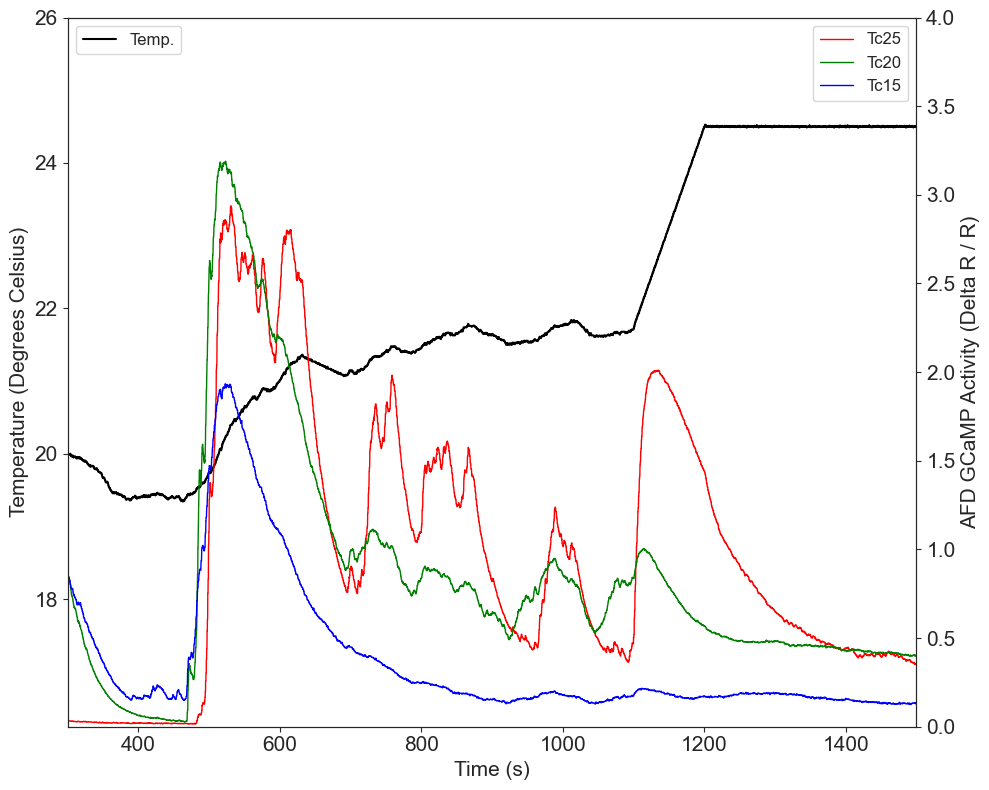

In [6]:
plt.clf()

fig = plt.subplots(nrows=1,ncols=1,figsize=(10,8))
ax1 = plt.subplot(1,1,1)
ax1.plot(Tc25['Time'][3000:], Tc25['Temp'][3000:], 'k')
ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize = 15)
ax1.set_xlabel('Time (s)', fontsize = 15)
ax1.set_ylim(16.25,26)
ax1.set_xlim(min(Tc25['Time']),max(Tc25['Time']))
ax1.legend(labels=['Temp.'], fontsize = 12, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax2 = ax1.twinx()
ax2.plot(Tc25['Time'][3000:], Tc25['Mean_Delta'][3000:], 'r', lw=1)
ax2.plot(Tc20['Time'][3000:], Tc20['Mean_Delta'][3000:], 'g', lw=1)
ax2.plot(Tc15['Time'][3000:], Tc15['Mean_Delta'][3000:], 'b', lw=1)
ax2.legend(labels=['Tc25', 'Tc20', 'Tc15'], fontsize = 12, loc='upper right')
ax2.set_ylabel('AFD GCaMP Activity (Delta R / R)', fontsize = 15)
ax2.set_ylim(0,4.0)
ax2.set_xlim(min(Tc25['Time'][3000:]),max(Tc25['Time']))
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.tight_layout()

#plt.savefig('VR_Tc25_Stim.png', dpi=600, bbox_inches='tight')
#plt.savefig('VR_Tc25_Stim.svg', dpi=600, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

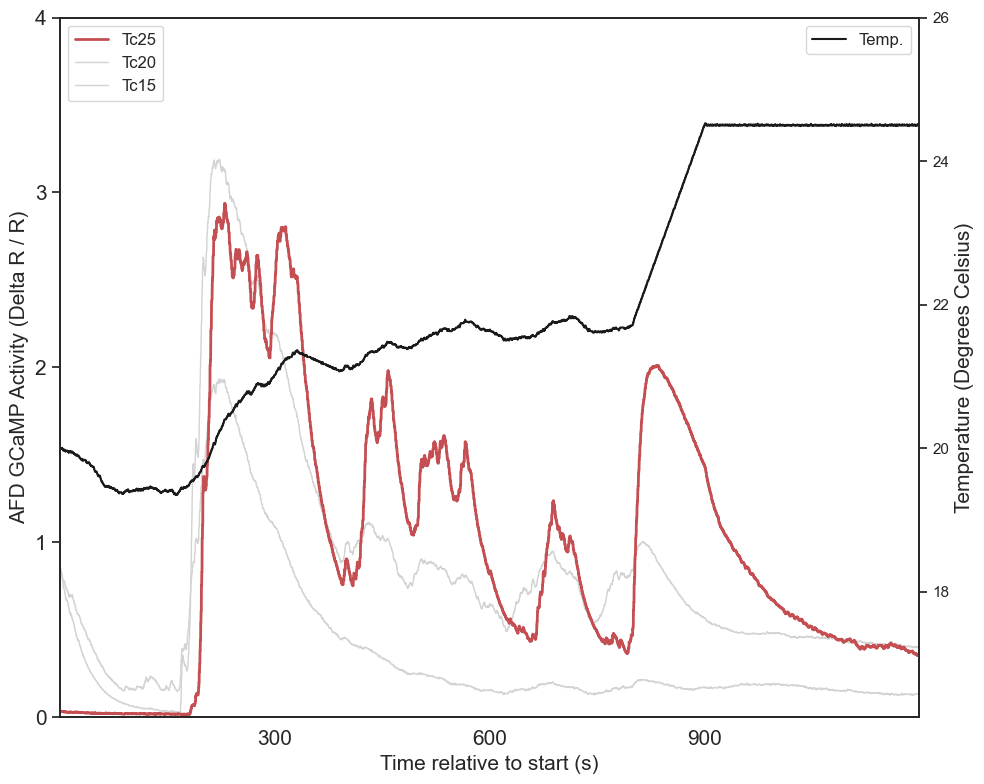

<Figure size 640x480 with 0 Axes>

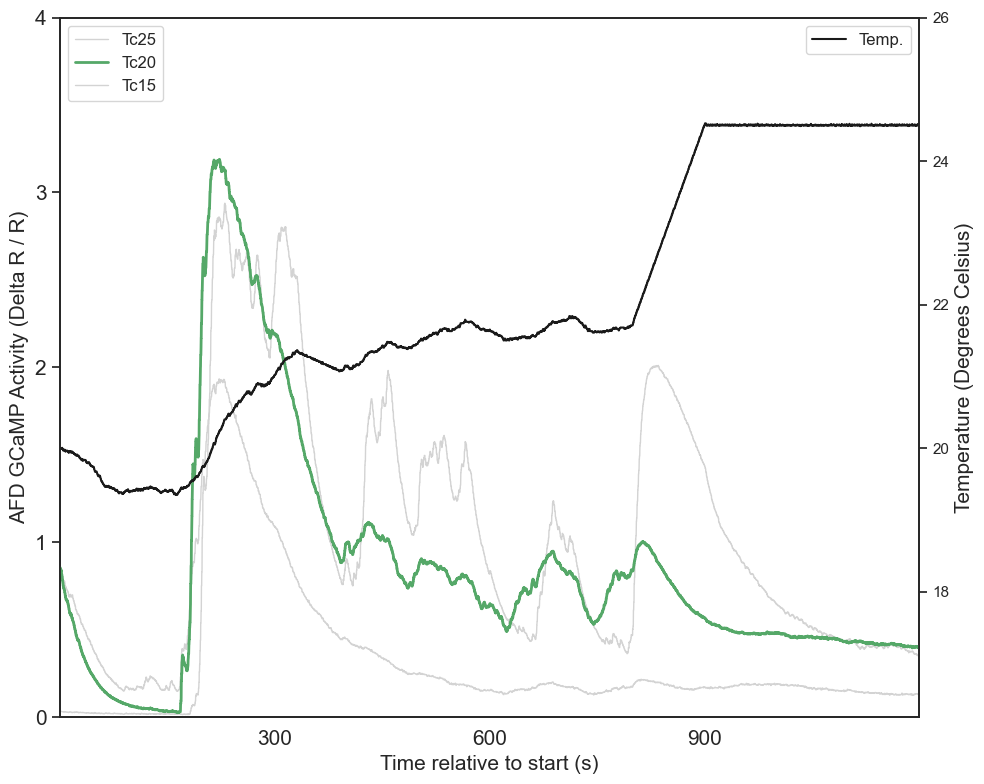

<Figure size 640x480 with 0 Axes>

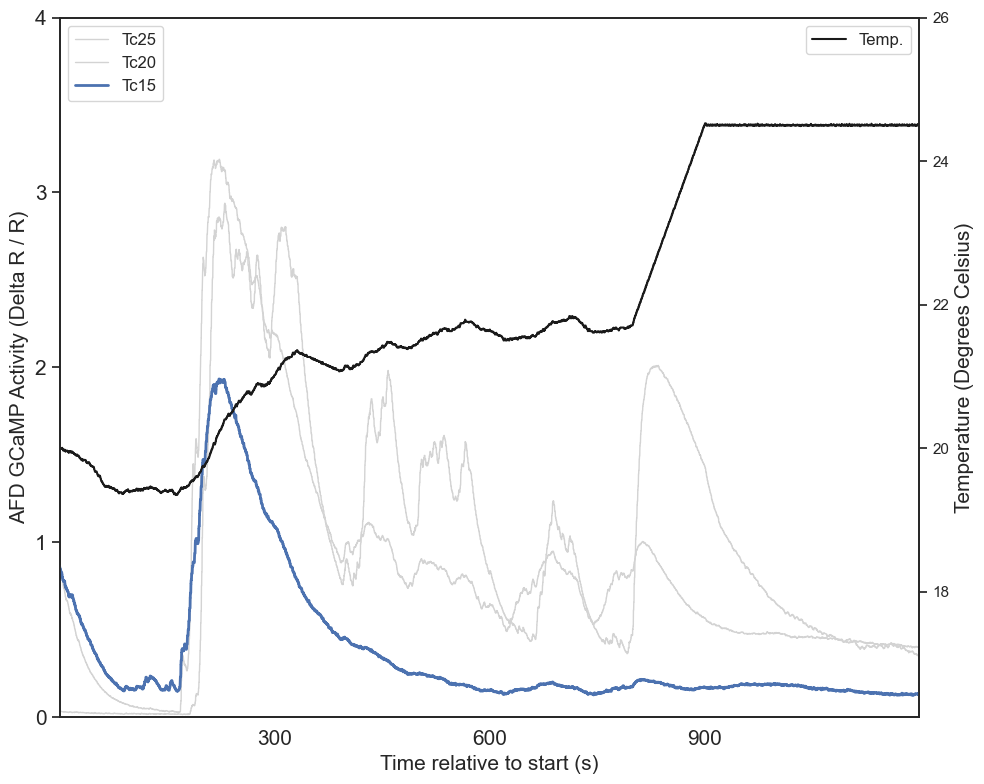

In [25]:
conditions = [
    {'data': Tc25, 'label': 'Tc25', 'color': 'r'},
    {'data': Tc20, 'label': 'Tc20', 'color': 'g'},
    {'data': Tc15, 'label': 'Tc15', 'color': 'b'}
]

for highlight_idx in range(3):
    plt.clf()
    fig, ax1 = plt.subplots(figsize=(10, 8))

    # --- Relative time ---
    t_start = Tc25['Time'][3000]
    relative_time_full = [t - t_start for t in Tc25['Time'][3000:]]

    # ----------------------------------------------------
    # LEFT AXIS: Calcium
    # ----------------------------------------------------
    for i, cond in enumerate(conditions):
        current_color = cond['color'] if i == highlight_idx else 'lightgray'
        current_lw = 2 if i == highlight_idx else 1
        current_zorder = 5 if i == highlight_idx else 1

        t_start_cond = cond['data']['Time'][3000]
        rel_time_cond = [t - t_start_cond for t in cond['data']['Time'][3000:]]

        ax1.plot(
            rel_time_cond,
            cond['data']['Mean_Delta'][3000:],
            color=current_color,
            lw=current_lw,
            zorder=current_zorder,
            label=cond['label']
        )

    ax1.set_ylabel('AFD GCaMP Activity (Delta R / R)', fontsize=15)
    ax1.set_ylim(0, 4.0)
    ax1.set_yticks([0, 1, 2, 3, 4])
    ax1.set_xlim(0, max(relative_time_full))
    ax1.set_xlim(0, max(relative_time_full))
    ax1.set_xticks([300, 600, 900])
    ax1.set_xlabel('Time relative to start (s)', fontsize=15)
    ax1.legend(loc='upper left', fontsize=12)
    ax1.tick_params(axis='both', labelsize=15)

    # ----------------------------------------------------
    # RIGHT AXIS: Temperature
    # ----------------------------------------------------
    ax2 = ax1.twinx()

    ax2.plot(
        relative_time_full,
        Tc25['Temp'][3000:],
        'k',
        label='Temp.'
    )

    ax2.set_ylabel('Temperature (Degrees Celsius)', fontsize=15)
    ax2.set_ylim(16.25, 26)
    ax2.set_xlim(0, max(relative_time_full))
    ax1.set_xlim(0, max(relative_time_full))
    ax1.set_xticks([300, 600, 900])
    ax2.legend(loc='upper right', fontsize=12)

    plt.tight_layout()
    plt.savefig(f'VR_Tc_Stim_Highlight_{conditions[highlight_idx]["label"]}.svg', dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

<Figure size 640x480 with 0 Axes>

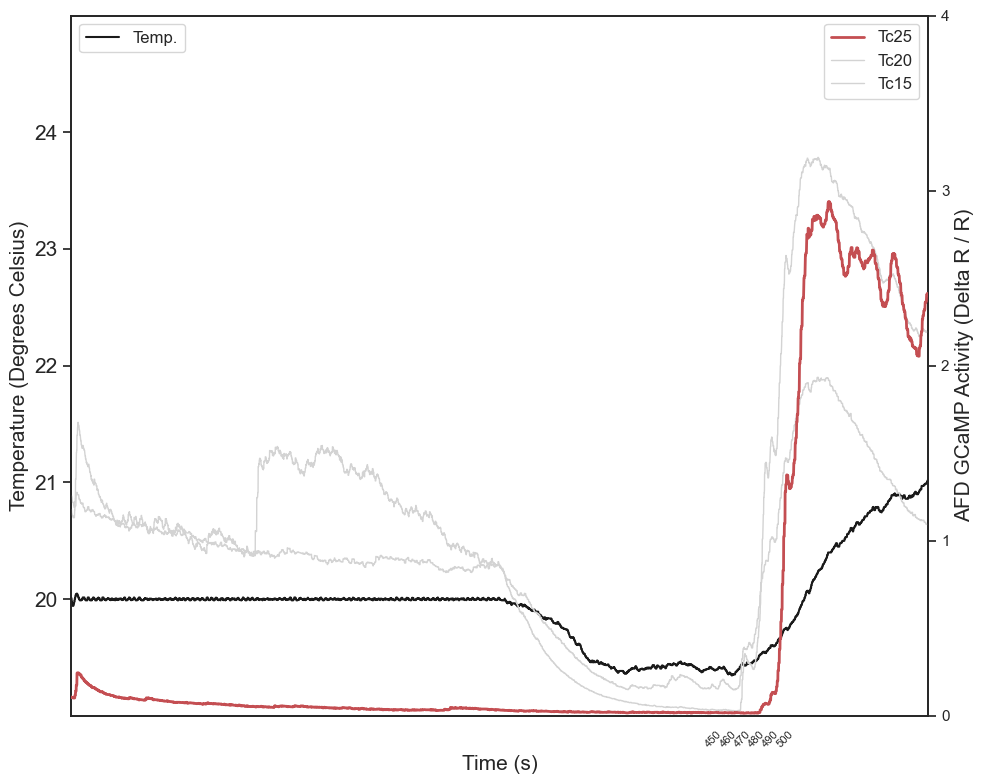

<Figure size 640x480 with 0 Axes>

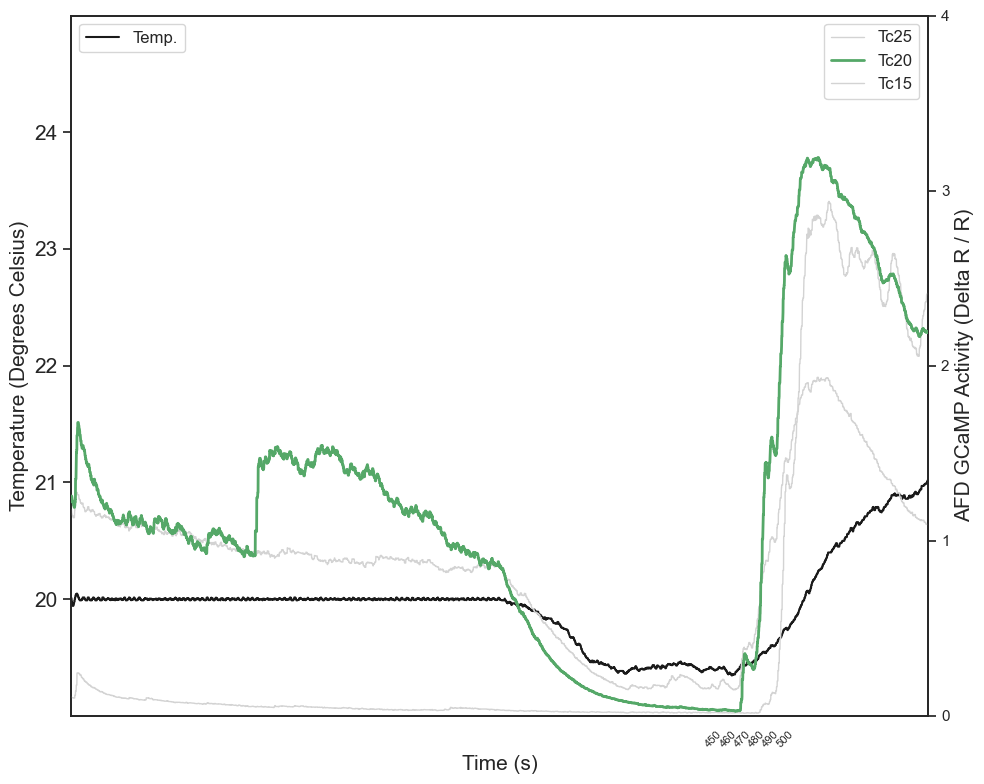

<Figure size 640x480 with 0 Axes>

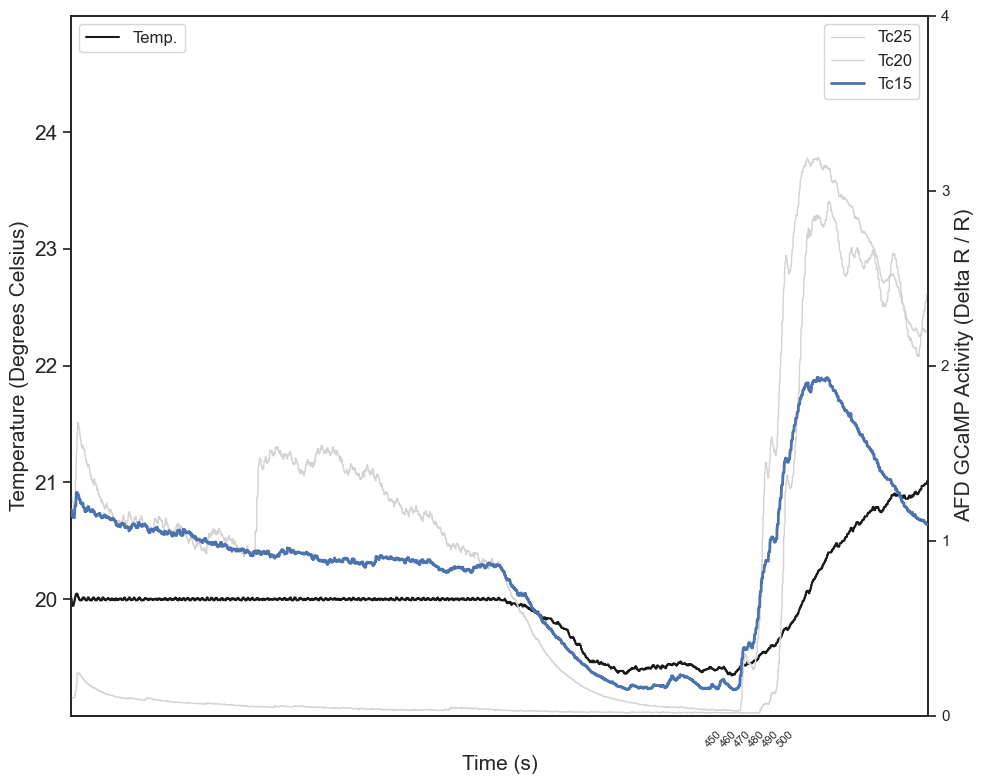

In [ ]:
# MDG 7/7/26 More ticks

conditions = [
    {'data': Tc25, 'label': 'Tc25', 'color': 'r'},
    {'data': Tc20, 'label': 'Tc20', 'color': 'g'},
    {'data': Tc15, 'label': 'Tc15', 'color': 'b'}
]

for highlight_idx in range(3):
    plt.clf()
    fig, ax1 = plt.subplots(figsize=(10, 8))
    
    # --- 1. PLOT TEMPERATURE ---
    # Using original timestamps from the data slice starting at index 3000
    ax1.plot(Tc25['Time'][0:6000], Tc25['Temp'][0:6000], 'k', label='Temp.')
    
    ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize=15)
    ax1.set_xlabel('Time (s)', fontsize=15) 
    ax1.set_ylim(19, 25)
    
    # Set the ticks
    ax1.set_xticks([450, 460, 470, 480, 490, 500]) 
    # Rotate the x-axis labels so they don't overlap <--
    ax1.tick_params(axis='x', rotation=45)
    
    # Set X-limits to the original timestamp range
    t_min = min(Tc25['Time'][0:6000])
    t_max = max(Tc25['Time'][0:6000])
    ax1.set_xlim(t_min, t_max)  
    ax1.set_yticks([20,21,22,23,24])
    ax1.legend(loc='upper left', fontsize=12)
    plt.tick_params(axis='y', labelsize=15) 
    ax1.tick_params(axis='x', labelsize=8) # Apply font size to x separately

    ax2 = ax1.twinx()
    
    # --- 2. PLOT CALCIUM TRACES ---
    for i, cond in enumerate(conditions):
        current_color = cond['color'] if i == highlight_idx else 'lightgray'
        current_lw = 2 if i == highlight_idx else 1
        current_zorder = 5 if i == highlight_idx else 1
        
        # Use standard time for each condition
        ax2.plot(cond['data']['Time'][0:6000], 
                 cond['data']['Mean_Delta'][0:6000], 
                 color=current_color, 
                 lw=current_lw, 
                 zorder=current_zorder,
                 label=cond['label'])

    # --- 3. FORMATTING AX2 ---
    ax2.set_ylabel('AFD GCaMP Activity (Delta R / R)', fontsize=15)
    ax2.set_ylim(0, 4.0)
    
    # Set Y-axis to 0-4 in steps of 1
    ax2.set_yticks([0, 1, 2, 3, 4]) 
    
    ax2.set_xlim(t_min, t_max)
    ax2.legend(loc='upper right', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    plt.close()

<Figure size 640x480 with 0 Axes>

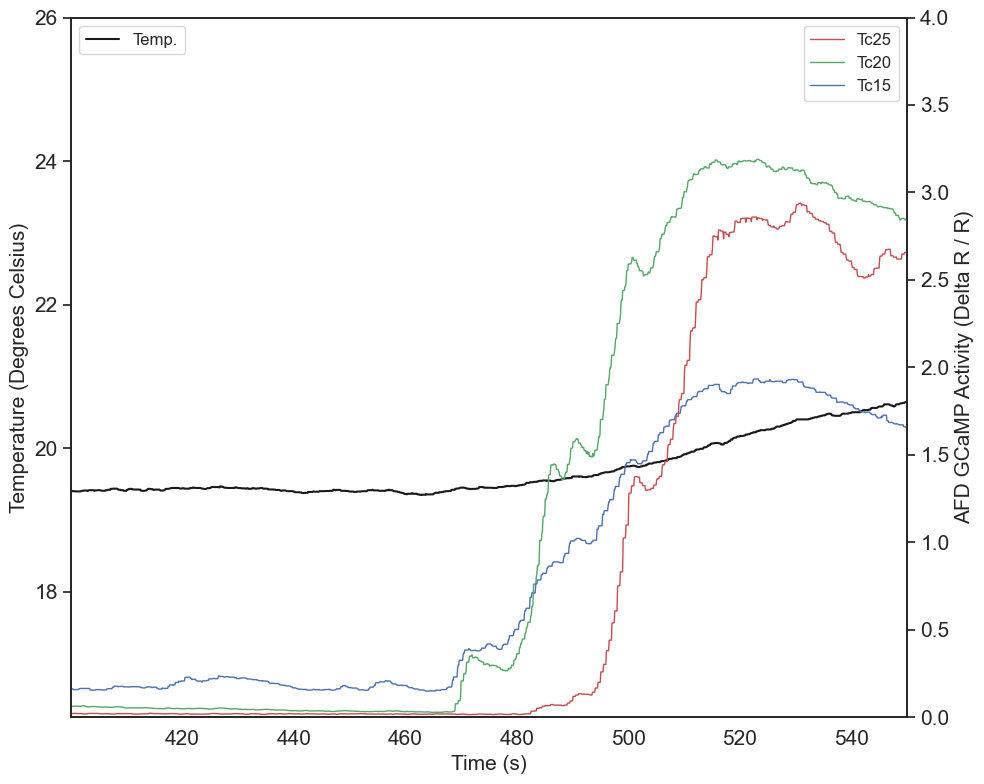

In [117]:
plt.clf()

fig = plt.subplots(nrows=1,ncols=1,figsize=(10,8))
ax1 = plt.subplot(1,1,1)
ax1.plot(Tc25['Time'][4000:5500], Tc25['Temp'][4000:5500], 'k')
ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize = 15)
ax1.set_xlabel('Time (s)', fontsize = 15)
ax1.set_ylim(16.25,26)
ax1.set_xlim(min(Tc25['Time'][4000:5500]),max(Tc25['Time'][4000:5500]))
ax1.legend(labels=['Temp.'], fontsize = 12, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax2 = ax1.twinx()
ax2.plot(Tc25['Time'][4000:5500], Tc25['Mean_Delta'][4000:5500], 'r', lw=1)
ax2.plot(Tc20['Time'][4000:5500], Tc20['Mean_Delta'][4000:5500], 'g', lw=1)
ax2.plot(Tc15['Time'][4000:5500], Tc15['Mean_Delta'][4000:5500], 'b', lw=1)
ax2.legend(labels=['Tc25', 'Tc20', 'Tc15'], fontsize = 12, loc='upper right')
ax2.set_ylabel('AFD GCaMP Activity (Delta R / R)', fontsize = 15)
ax2.set_ylim(0,4.0)
ax2.set_xlim(min(Tc25['Time'][4000:5500]),max(Tc25['Time'][4000:5500]))
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.tight_layout()

#plt.savefig('VR_Tc25_Stim.png', dpi=600, bbox_inches='tight')
#plt.savefig('VR_Tc25_Stim.svg', dpi=600, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

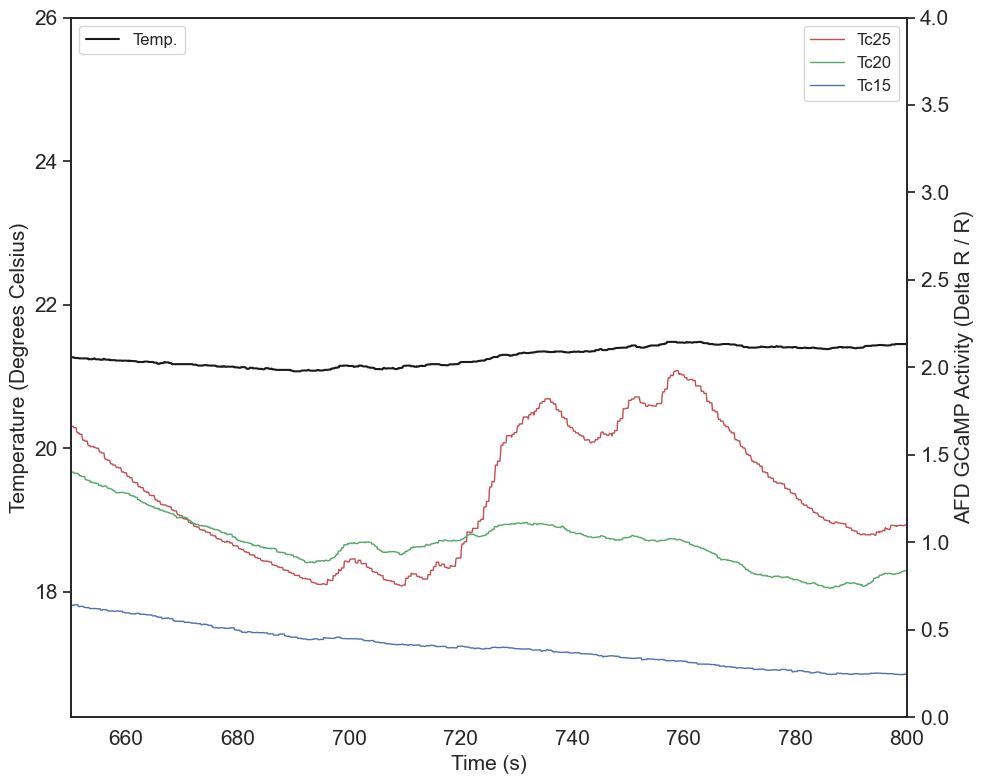

In [18]:
plt.clf()

fig = plt.subplots(nrows=1,ncols=1,figsize=(10,8))
ax1 = plt.subplot(1,1,1)
ax1.plot(Tc25['Time'][6500:8000], Tc25['Temp'][6500:8000], 'k')
ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize = 15)
ax1.set_xlabel('Time (s)', fontsize = 15)
ax1.set_ylim(16.25,26)
ax1.set_xlim(min(Tc25['Time'][6500:8000]),max(Tc25['Time'][6500:8000]))
ax1.legend(labels=['Temp.'], fontsize = 12, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax2 = ax1.twinx()
ax2.plot(Tc25['Time'][6500:8000], Tc25['Mean_Delta'][6500:8000], 'r', lw=1)
ax2.plot(Tc20['Time'][6500:8000], Tc20['Mean_Delta'][6500:8000], 'g', lw=1)
ax2.plot(Tc15['Time'][6500:8000], Tc15['Mean_Delta'][6500:8000], 'b', lw=1)
ax2.legend(labels=['Tc25', 'Tc20', 'Tc15'], fontsize = 12, loc='upper right')
ax2.set_ylabel('AFD GCaMP Activity (Delta R / R)', fontsize = 15)
ax2.set_ylim(0,4.0)
ax2.set_xlim(min(Tc25['Time'][6500:8000]),max(Tc25['Time'][6500:8000]))
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.tight_layout()

#plt.savefig('VR_Tc25_Stim.png', dpi=600, bbox_inches='tight')
#plt.savefig('VR_Tc25_Stim.svg', dpi=600, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

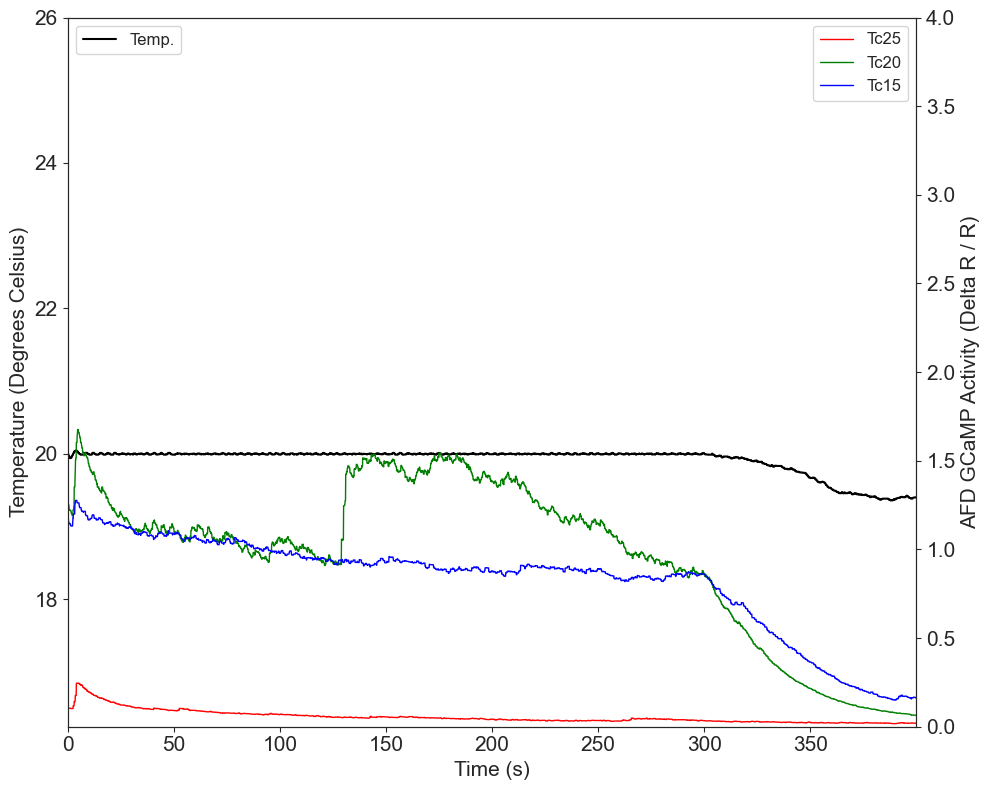

In [5]:
plt.clf()

fig = plt.subplots(nrows=1,ncols=1,figsize=(10,8))
ax1 = plt.subplot(1,1,1)
ax1.plot(Tc25['Time'][0:4000], Tc25['Temp'][0:4000], 'k')
ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize = 15)
ax1.set_xlabel('Time (s)', fontsize = 15)
ax1.set_ylim(16.25,26)
ax1.set_xlim(min(Tc25['Time'][0:4000]),max(Tc25['Time'][0:4000]))
ax1.legend(labels=['Temp.'], fontsize = 12, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax2 = ax1.twinx()
ax2.plot(Tc25['Time'][0:4000], Tc25['Mean_Delta'][0:4000], 'r', lw=1)
ax2.plot(Tc20['Time'][0:4000], Tc20['Mean_Delta'][0:4000], 'g', lw=1)
ax2.plot(Tc15['Time'][0:4000], Tc15['Mean_Delta'][0:4000], 'b', lw=1)
ax2.legend(labels=['Tc25', 'Tc20', 'Tc15'], fontsize = 12, loc='upper right')
ax2.set_ylabel('AFD GCaMP Activity (Delta R / R)', fontsize = 15)
ax2.set_ylim(0,4.0)
ax2.set_xlim(min(Tc25['Time'][0:4000]),max(Tc25['Time'][0:4000]))
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.tight_layout()

#plt.savefig('VR_Tc25_Stim.png', dpi=600, bbox_inches='tight')
#plt.savefig('VR_Tc25_Stim.svg', dpi=600, bbox_inches='tight')

# Tc25 Stimulus Downshifted VR

In [13]:
Tc20['Time'][4800]

480.115125

<Figure size 640x480 with 0 Axes>

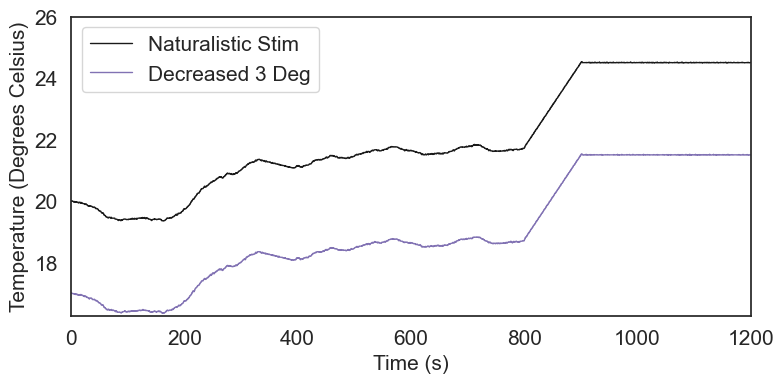

In [18]:
segment = 'seg4'
plt.clf()
fig = plt.subplots(nrows=1,ncols=1,figsize=(8,4))

ax1 = plt.subplot(1,1,1)
ax1.plot(relative_time_full, Tc20['Temp'][3000:], 'k', lw=1)
ax1.plot(relative_time_full, Tc20_DOWN3['Temp'][3000:], 'm', lw=1)
ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize = 15)
ax1.set_xlabel('Time (s)', fontsize = 15)
ax1.set_ylim(16.25,26)
ax1.set_xlim(0, max(relative_time_full))
ax1.legend(labels=['Naturalistic Stim', 'Decreased 3 Deg'], fontsize = 15, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.tight_layout()
#plt.savefig('VR_Tc25&DownshiftStims.svg', dpi=600, bbox_inches='tight')
plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

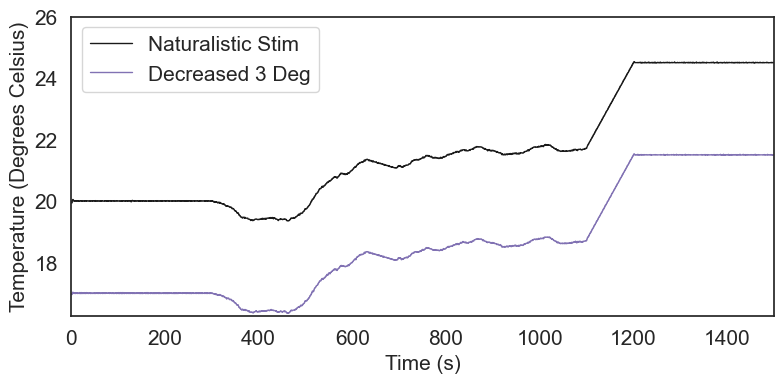

In [19]:
segment = 'seg4'
plt.clf()
fig = plt.subplots(nrows=1,ncols=1,figsize=(8,4))

ax1 = plt.subplot(1,1,1)
#ax1.plot(relative_time_full, Tc25['Temp'][3000:], 'k', lw=1)
ax1.plot(Tc20['Time'], Tc20['Temp'], 'k', lw=1)
ax1.plot(Tc20_DOWN3['Time'][0:], Tc20_DOWN3['Temp'][0:], 'm', lw=1)
ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize = 15)
ax1.set_xlabel('Time (s)', fontsize = 15)
ax1.set_ylim(16.25,26)
ax1.set_xlim(0, max(Tc20_DOWN3['Time'][0:]))
ax1.legend(labels=['Naturalistic Stim', 'Decreased 3 Deg'], fontsize = 15, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.tight_layout()
#plt.savefig('VR_Tc25&DownshiftStims.svg', dpi=600, bbox_inches='tight')
plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

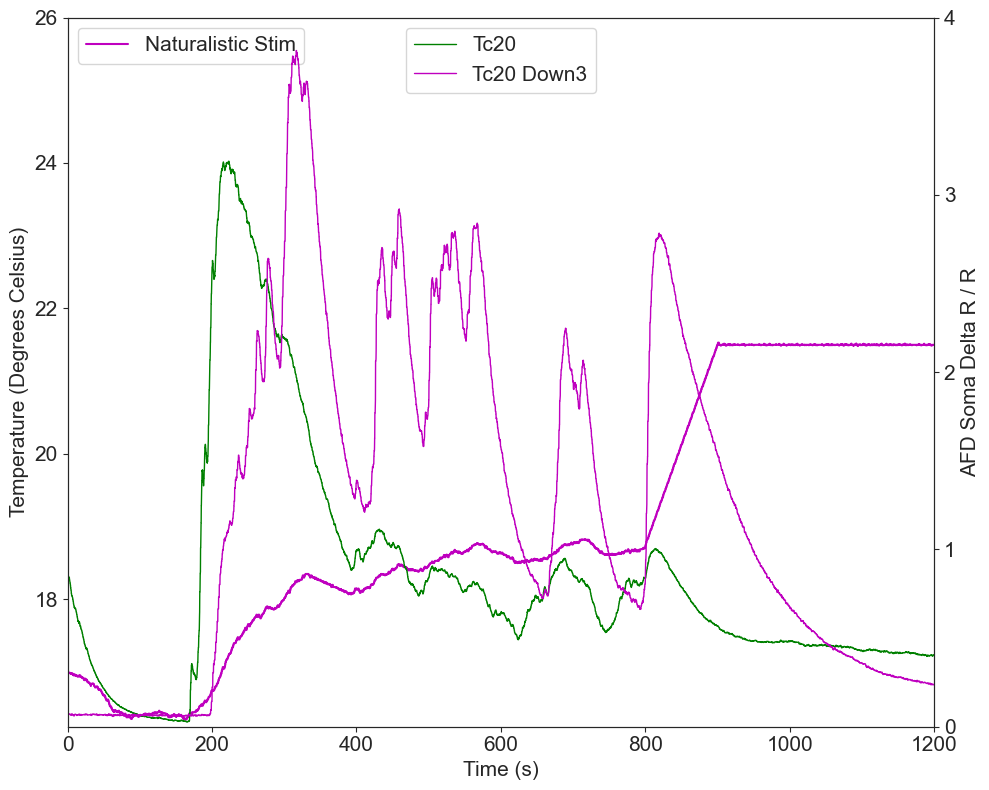

In [10]:
segment = 'seg4'
plt.clf()
fig = plt.subplots(nrows=1,ncols=1,figsize=(10,8))#,dpi=300)#plt.ylim(0,1)

ax1 = plt.subplot(1,1,1)
ax1.plot(relative_time_full, Tc20_DOWN3['Temp'][3000:], 'm')
ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize = 15)
ax1.set_xlabel('Time (s)', fontsize = 15)
ax1.set_ylim(16.25,26)
ax1.set_xlim(0, max(relative_time_full))
ax1.legend(labels=['Naturalistic Stim', 'Decreased 3 Deg'], fontsize = 15, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax2 = ax1.twinx()
ax2.plot(relative_time_full, Tc20['Mean_Delta'][3000:], 'g', lw=1)
ax2.plot(relative_time_full, Tc20_DOWN3['Mean_Delta'][3000:], 'm', lw=1)
ax2.legend(labels=['Tc20', 'Tc20 Down3'], fontsize = 15, loc='upper center')

ax2.set_ylabel('AFD Soma Delta R / R', fontsize = 15)
ax2.set_ylim(0,4.0)
ax2.set_xlim(0, max(relative_time_full))
ax2.set_yticks([0, 1, 2, 3, 4])
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)


plt.tight_layout()


#plt.savefig('VR_DownshiftStim.svg', dpi=600, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

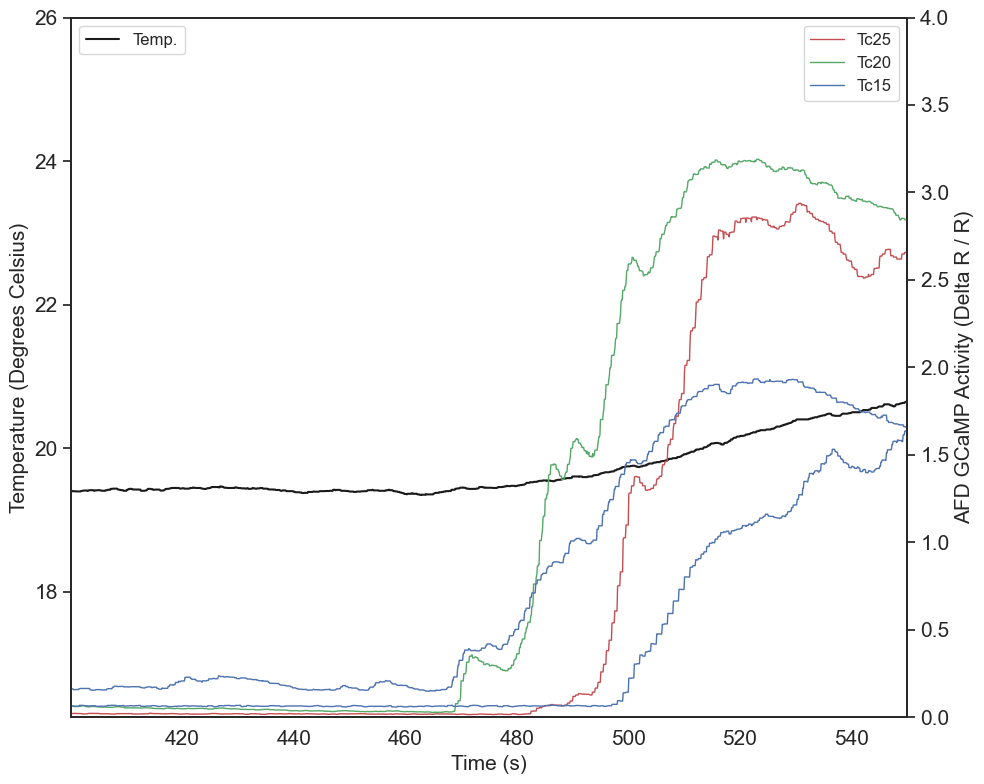

In [118]:
plt.clf()

fig = plt.subplots(nrows=1,ncols=1,figsize=(10,8))
ax1 = plt.subplot(1,1,1)
ax1.plot(Tc25['Time'][4000:5500], Tc25['Temp'][4000:5500], 'k')
ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize = 15)
ax1.set_xlabel('Time (s)', fontsize = 15)
ax1.set_ylim(16.25,26)
ax1.set_xlim(min(Tc25['Time'][4000:5500]),max(Tc25['Time'][4000:5500]))
ax1.legend(labels=['Temp.'], fontsize = 12, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax2 = ax1.twinx()
ax2.plot(Tc25['Time'][4000:5500], Tc25['Mean_Delta'][4000:5500], 'r', lw=1)
ax2.plot(Tc20['Time'][4000:5500], Tc20['Mean_Delta'][4000:5500], 'g', lw=1)
ax2.plot(Tc15['Time'][4000:5500], Tc15['Mean_Delta'][4000:5500], 'b', lw=1)
ax2.plot(Tc20_DOWN3['Time'][4000:5500], Tc20_DOWN3['Mean_Delta'][4000:5500], 'b', lw=1)
ax2.legend(labels=['Tc25', 'Tc20', 'Tc15'], fontsize = 12, loc='upper right')
ax2.set_ylabel('AFD GCaMP Activity (Delta R / R)', fontsize = 15)
ax2.set_ylim(0,4.0)
ax2.set_xlim(min(Tc25['Time'][4000:5500]),max(Tc25['Time'][4000:5500]))
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.tight_layout()

#plt.savefig('VR_Tc25_Stim.png', dpi=600, bbox_inches='tight')
#plt.savefig('VR_Tc25_Stim.svg', dpi=600, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

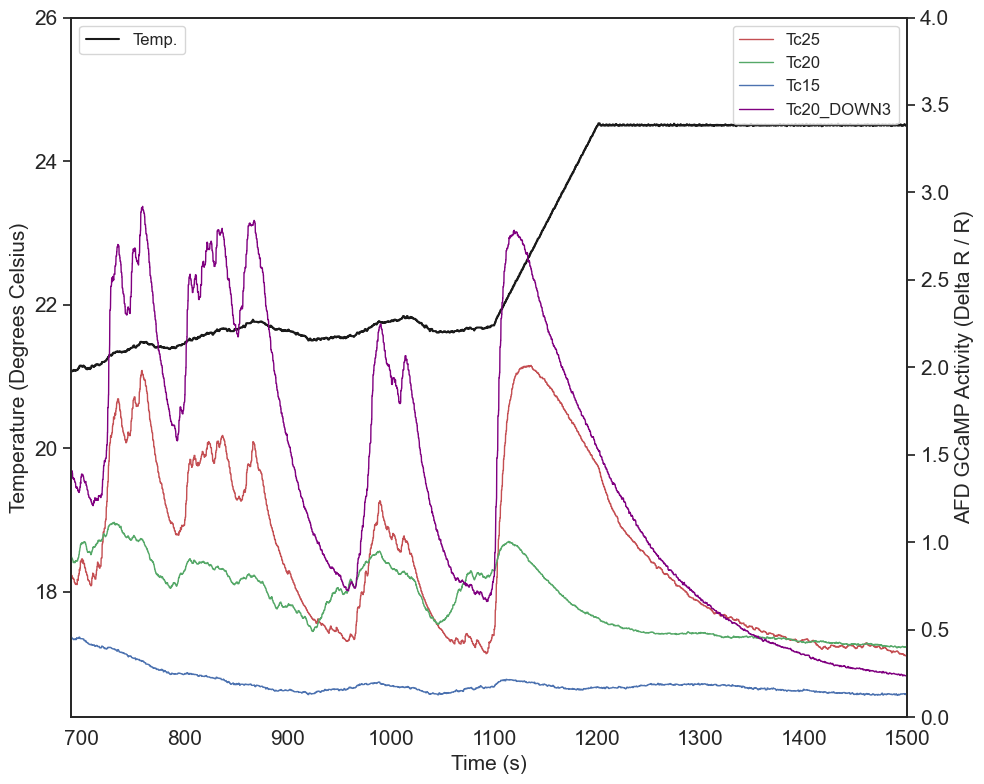

In [42]:
plt.clf()

fig = plt.subplots(nrows=1,ncols=1,figsize=(10,8))
ax1 = plt.subplot(1,1,1)
ax1.plot(Tc25['Time'][6900:], Tc25['Temp'][6900:], 'k')
ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize = 15)
ax1.set_xlabel('Time (s)', fontsize = 15)
ax1.set_ylim(16.25,26)
ax1.set_xlim(min(Tc25['Time'][6900:]),max(Tc25['Time'][6900:]))
ax1.legend(labels=['Temp.'], fontsize = 12, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax2 = ax1.twinx()
ax2.plot(Tc25['Time'][6900:], Tc25['Mean_Delta'][6900:], 'r', lw=1)
ax2.plot(Tc20['Time'][6900:], Tc20['Mean_Delta'][6900:], 'g', lw=1)
ax2.plot(Tc15['Time'][6900:], Tc15['Mean_Delta'][6900:], 'b', lw=1)
ax2.plot(Tc20_DOWN3['Time'][6900:], Tc20_DOWN3['Mean_Delta'][6900:], 'purple', lw=1)
ax2.legend(labels=['Tc25', 'Tc20', 'Tc15', 'Tc20_DOWN3'], fontsize = 12, loc='upper right')
ax2.set_ylabel('AFD GCaMP Activity (Delta R / R)', fontsize = 15)
ax2.set_ylim(0,4.0)
ax2.set_xlim(min(Tc25['Time'][6900:]),max(Tc25['Time'][6900:]))
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.tight_layout()

#plt.savefig('VR_Tc25_Stim.png', dpi=600, bbox_inches='tight')
#plt.savefig('VR_Tc25_Stim.svg', dpi=600, bbox_inches='tight')

# Comparing Response Thresholds between conditions

In [8]:
def find_AFD_deriv_and_response_thresh(AFD_data, threshold = 0.01, start_frame = 4900):
    # Get the number of individual samples/worms
    num_samples = len(AFD_data['Scaled'])
    
    # Initialize arrays/lists to store per-sample data
    All_Derivs = np.zeros(np.shape(AFD_data['Scaled']))
    All_Response_frames = []
    All_Response_temps = []
    
    # Loop over each individual sample
    for j in range(num_samples):
        trace = AFD_data['Scaled'][j, :]
        
        # Calculate derivative for this specific sample
        deriv = [0]
        deriv.extend(list(np.diff(trace)))
        All_Derivs[j, :] = deriv
        
        # Fallback values in case the threshold is never reached
        Response_frame = np.nan
        Response_temp = np.nan
        
        # Scan forward to find the threshold crossing
        for i in range(start_frame, len(deriv)):
            if deriv[i] > threshold:
                Response_frame = i
                Response_temp = AFD_data['Temp'][Response_frame]
                break
                
        # Store the individual results
        All_Response_frames.append(Response_frame)
        All_Response_temps.append(Response_temp)
        
    return All_Derivs, All_Response_frames, All_Response_temps

In [10]:
st_frame = 4650
Tc20_DOWN3derivs, Tc20_DOWN3frames, Tc20_DOWN3temps = find_AFD_deriv_and_response_thresh(Tc20_DOWN3, threshold = 0.01, start_frame = st_frame)
Tc25derivs, Tc25frames, Tc25temps = find_AFD_deriv_and_response_thresh(Tc25, threshold = 0.01, start_frame = st_frame)
Tc20derivs, Tc20frames, Tc20temps = find_AFD_deriv_and_response_thresh(Tc20, threshold = 0.01, start_frame = st_frame)
Tc15derivs, Tc15frames, Tc15temps = find_AFD_deriv_and_response_thresh(Tc15, threshold = 0.01, start_frame = st_frame)


 ANALYZING: Response Time



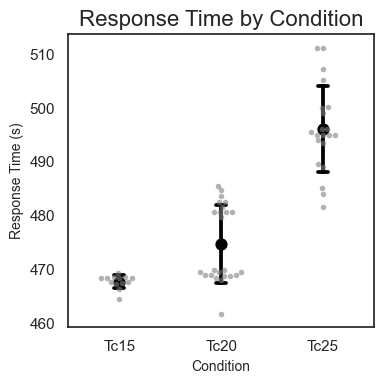


--- 1. Shapiro-Wilk Normality Test (Time) ---
Tc15: p-value = 0.0226
Tc20: p-value = 0.0014
Tc25: p-value = 0.3391

[Result]: Data violates normality. Running Non-Parametric Tests.

--- 2. Kruskal-Wallis Omnibus Test (Time) ---
p-value = 1.7734e-10

--- 3. Pairwise Mann-Whitney U Tests (Holm-Bonferroni Corrected) ---
Tc15 vs Tc20: p_adj = 4.8483e-05 (*)
Tc15 vs Tc25: p_adj = 2.7874e-06 (*)
Tc20 vs Tc25: p_adj = 1.0004e-07 (*)

 ANALYZING: Response Temp



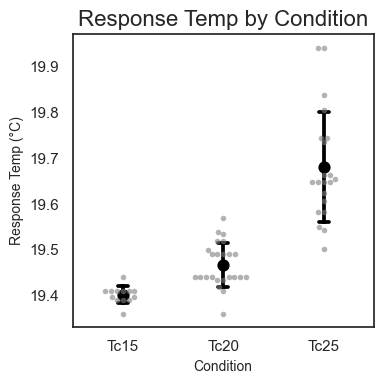


--- 1. Shapiro-Wilk Normality Test (Temp) ---
Tc15: p-value = 0.0728
Tc20: p-value = 0.1200
Tc25: p-value = 0.0708

[Result]: Temp data is normally distributed. Running Parametric Tests.

--- 2. One-Way ANOVA (Temp) ---
F-statistic = 62.7248, p-value = 6.4593e-15

--- 3. Pairwise Tukey HSD Tests ---
Tc15 vs Tc20: p_adj = 5.2300e-02 (ns)
Tc15 vs Tc25: p_adj = 0.0000e+00 (*)
Tc20 vs Tc25: p_adj = 0.0000e+00 (*)


In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from itertools import combinations
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# --- HELPER: Safely extract either Time or Temp using frame indices ---
def safe_extract_metric(frames, dataset, metric):
    """
    Extracts the chosen metric ('Time' or 'Temp') from the dataset based on frame index.
    Safely handles single numbers or lists to prevent iteration crashes.
    """
    if isinstance(frames, (int, float, np.integer, np.floating)):
        frames = [frames]
        
    vals = []
    for f in frames:
        if pd.notna(f):  # Check if it's a valid number and not NaN
            vals.append(dataset[metric][int(f)])
        else:
            vals.append(np.nan)
    return vals

def plot_and_analyze_metric(data_dict, metric='Time', saveFig = None):
    """
    Generates a swarmplot/pointplot and runs nonparametric/parametric statistics for a given metric.
    data_dict: Dictionary formatted as {'Label': (Dataset, Frames_list)}
    metric: string, either 'Time' or 'Temp'
    """
    print(f"\n=========================================================")
    print(f" ANALYZING: Response {metric}")
    print(f"=========================================================\n")
    
    all_vals = []
    all_conds = []
    
    # 1. Dynamically loop through whatever datasets were passed in
    for condition_name, (dataset, frames) in data_dict.items():
        vals = safe_extract_metric(frames, dataset, metric)
        all_vals.extend(vals)
        all_conds.extend([condition_name] * len(vals))

    # 2. Create the DataFrame
    col_name = f'Response {metric}'
    df = pd.DataFrame({
        'Condition': all_conds,
        col_name: all_vals
    })

    # --- 3. Create the Plot ---
    sns.set_theme(style="white")
    plt.figure(figsize=(4, 4))

    # Plot 1: The individual data points
    sns.swarmplot(
        data=df,
        x='Condition',
        y=col_name,
        alpha=0.6,
        color='gray',
        size=4        
    )

    # Plot 2: The mean and standard deviation (point plot)
    sns.pointplot(
        data=df,
        x='Condition',
        y=col_name,
        linestyle='none',  
        errorbar='sd',     
        color='black',
        capsize=0.1
    )

    # Finalize labels based on the chosen metric
    unit = "(s)" if metric == 'Time' else "(°C)"
    
    plt.title(f'Response {metric} by Condition', fontsize=16)
    plt.xlabel('Condition', fontsize=10)
    plt.ylabel(f'Response {metric} {unit}', fontsize=10) 

    plt.tight_layout()
    if saveFig:
        plt.savefig(saveFig, dpi=600, bbox_inches='tight')
    plt.show()

    # =========================================================
    # --- 4. STATISTICAL ANALYSIS ---
    # =========================================================
    # Drop NaNs before doing stats
    df_stats = df.dropna()
    conds = df_stats['Condition'].unique()
    
    if len(conds) < 2:
        print("Not enough groups to perform statistical comparison.")
        return

    print(f"\n--- 1. Shapiro-Wilk Normality Test ({metric}) ---")
    is_normal = True
    for c in conds:
        group_data = df_stats[df_stats['Condition'] == c][col_name]
        if len(group_data) >= 3:
            stat, p = stats.shapiro(group_data)
            print(f"{c}: p-value = {p:.4f}")
            if p < 0.05:
                is_normal = False
                
    # Extract the data arrays for Omnibus testing
    groups_data = [df_stats[df_stats['Condition'] == c][col_name] for c in conds]

    if not is_normal:
        print("\n[Result]: Data violates normality. Running Non-Parametric Tests.")
        
        # Kruskal-Wallis Omnibus Test
        h_stat, p_kw = stats.kruskal(*groups_data)
        print(f"\n--- 2. Kruskal-Wallis Omnibus Test ({metric}) ---")
        print(f"p-value = {p_kw:.4e}")
        
        if p_kw < 0.05:
            print("\n--- 3. Pairwise Mann-Whitney U Tests (Holm-Bonferroni Corrected) ---")
            comparisons = list(combinations(conds, 2))
            
            raw_p_values = []
            for c1, c2 in comparisons:
                g1 = df_stats[df_stats['Condition'] == c1][col_name]
                g2 = df_stats[df_stats['Condition'] == c2][col_name]
                u_stat, p_mw = stats.mannwhitneyu(g1, g2, alternative='two-sided')
                raw_p_values.append(p_mw)
            
            # Apply Holm step-down correction
            reject, holm_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')
            
            # Print corrected results
            for i, (c1, c2) in enumerate(comparisons):
                sig = "*" if reject[i] else "ns"
                print(f"{c1} vs {c2}: p_adj = {holm_p_values[i]:.4e} ({sig})")
                
        else:
            print(f"\nNo significant differences found across groups for {metric} (Kruskal-Wallis p > 0.05).")
            
    else:
        print(f"\n[Result]: {metric} data is normally distributed. Running Parametric Tests.")
        
        # One-Way ANOVA
        f_stat, p_anova = stats.f_oneway(*groups_data)
        print(f"\n--- 2. One-Way ANOVA ({metric}) ---")
        print(f"F-statistic = {f_stat:.4f}, p-value = {p_anova:.4e}")
        
        if p_anova < 0.05:
            if len(conds) > 2:
                print("\n--- 3. Pairwise Tukey HSD Tests ---")
                # Tukey automatically applies multiple comparison corrections
                tukey_result = pairwise_tukeyhsd(endog=df_stats[col_name], groups=df_stats['Condition'], alpha=0.05)
                
                # Extract and print in a clean format matching the Mann-Whitney output
                for row in tukey_result._results_table.data[1:]:
                    c1, c2, _, p_adj, _, _, reject = row
                    sig = "*" if reject else "ns"
                    print(f"{c1} vs {c2}: p_adj = {p_adj:.4e} ({sig})")
            else:
                print("\nOnly 2 groups detected; ANOVA p-value acts as the test of significance (no post-hoc needed).")
        else:
            print(f"\nNo significant differences found across groups for {metric} (ANOVA p > 0.05).")

# =========================================================
# HOW TO USE IT
# =========================================================
# 1. Package whatever datasets you want to compare into a dictionary. 
# Format is 'Your Label Name': (The Dataset, The Frames)

#  Comparing all 4 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
compare_all = {
    'Tc15': (Tc15, Tc15frames),
    'Tc20': (Tc20, Tc20frames),
    'Tc25': (Tc25, Tc25frames),
    'Tc20 Down 3': (Tc20_DOWN3, Tc20_DOWN3frames)
}
#plot_and_analyze_metric(compare_all, metric='Time')
#plot_and_analyze_metric(compare_all, metric='Temp')

#  Comparing 3 Tc: 15, 20, 25  ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
compare_three = {
    'Tc15': (Tc15, Tc15frames),
    'Tc20': (Tc20, Tc20frames),
    'Tc25': (Tc25, Tc25frames)
}
saveFigtime = "C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/VR_Naturalistic_with_Downshift_Stim/pt1_CompTime.svg"
saveFigtemp = "C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/VR_Naturalistic_with_Downshift_Stim/pt1_CompTemp.svg"
plot_and_analyze_metric(compare_three, metric='Time', saveFig=saveFigtime)
plot_and_analyze_metric(compare_three, metric='Temp', saveFig=saveFigtemp)

# Comparing just the 2 Tc20 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
compare_two = {
    'Tc20 Normal': (Tc20, Tc20frames),
    'Tc20 Shifted': (Tc20_DOWN3, Tc20_DOWN3frames)
}
#plot_and_analyze_metric(compare_two, metric='Time', saveFig)
#plot_and_analyze_metric(compare_two, metric='Temp', saveFig)




In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from itertools import combinations
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# --- HELPER: Safely extract and normalize metric ---
def safe_extract_metric(dataset, frames, metric, start_frame=None):
    """
    Extracts the chosen metric ('Time' or 'Temp') from the dataset.
    If metric is 'Time' and start_frame is provided, normalize relative to start_frame.
    """
    if isinstance(frames, (int, float, np.integer, np.floating)):
        frames = [frames]
        
    vals = []
    # Calculate baseline for normalization if applicable
    baseline = 0
    if metric == 'Time' and start_frame is not None:
        baseline = dataset[metric][int(start_frame)]

    for f in frames:
        if pd.notna(f):
            raw_val = dataset[metric][int(f)]
            if metric == 'Time' and start_frame is not None:
                vals.append(raw_val - baseline)
            else:
                vals.append(raw_val)
        else:
            vals.append(np.nan)
    return vals

def plot_and_analyze_metric(data_dict, metric='Time', start_frame=None, saveFig=None):
    """
    Generates a swarmplot/pointplot and runs the full statistical pipeline.
    data_dict: Dictionary formatted as {'Label': (Dataset, Frames_list)}
    metric: string, either 'Time' or 'Temp'
    start_frame: int, frame index used to normalize Time (optional)
    """
    print(f"\n=========================================================")
    print(f" ANALYZING: Response {metric}" + (f" (Relative to frame {start_frame})" if start_frame is not None else ""))
    print(f"=========================================================\n")
    
    all_vals = []
    all_conds = []
    
    for condition_name, (dataset, frames) in data_dict.items():
        vals = safe_extract_metric(dataset, frames, metric, start_frame=start_frame)
        all_vals.extend(vals)
        all_conds.extend([condition_name] * len(vals))

    df = pd.DataFrame({'Condition': all_conds, f'Response {metric}': all_vals})
    col_name = f'Response {metric}'

    # --- 3. Plotting ---
    sns.set_theme(style="white")
    plt.figure(figsize=(4, 4))
    sns.swarmplot(data=df, x='Condition', y=col_name, alpha=0.6, color='gray', size=4)
    sns.pointplot(data=df, x='Condition', y=col_name, linestyle='none', errorbar='sd', color='black', capsize=0.1)

    unit = "(s)" if metric == 'Time' else "(°C)"
    plt.title(f'Response {metric} by Condition', fontsize=16)
    plt.ylabel(f'Response {metric} {unit}', fontsize=12) 
    plt.tight_layout()
    if saveFig: plt.savefig(saveFig, dpi=600, bbox_inches='tight')
    plt.show()

    # =========================================================
    # --- 4. FULL STATISTICAL PIPELINE (Restored) ---
    # =========================================================
    df_stats = df.dropna()
    conds = df_stats['Condition'].unique()
    
    if len(conds) < 2:
        print("Not enough groups to perform statistical comparison.")
        return

    print(f"\n--- 1. Shapiro-Wilk Normality Test ({metric}) ---")
    is_normal = True
    for c in conds:
        group_data = df_stats[df_stats['Condition'] == c][col_name]
        if len(group_data) >= 3:
            stat, p = stats.shapiro(group_data)
            print(f"{c}: p-value = {p:.4f}")
            if p < 0.05: is_normal = False
                
    groups_data = [df_stats[df_stats['Condition'] == c][col_name] for c in conds]

    if not is_normal:
        print("\n[Result]: Data violates normality. Running Non-Parametric Tests.")
        h_stat, p_kw = stats.kruskal(*groups_data)
        print(f"\n--- 2. Kruskal-Wallis Omnibus Test ({metric}) ---")
        print(f"p-value = {p_kw:.4e}")
        
        if p_kw < 0.05:
            print("\n--- 3. Pairwise Mann-Whitney U Tests (Holm-Bonferroni Corrected) ---")
            comparisons = list(combinations(conds, 2))
            raw_p_values = []
            for c1, c2 in comparisons:
                g1 = df_stats[df_stats['Condition'] == c1][col_name]
                g2 = df_stats[df_stats['Condition'] == c2][col_name]
                u_stat, p_mw = stats.mannwhitneyu(g1, g2, alternative='two-sided')
                raw_p_values.append(p_mw)
            
            reject, holm_p_values, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')
            for i, (c1, c2) in enumerate(comparisons):
                sig = "*" if reject[i] else "ns"
                print(f"{c1} vs {c2}: p_adj = {holm_p_values[i]:.4e} ({sig})")
    else:
        print(f"\n[Result]: {metric} data is normally distributed. Running Parametric Tests.")
        f_stat, p_anova = stats.f_oneway(*groups_data)
        print(f"\n--- 2. One-Way ANOVA ({metric}) ---")
        print(f"F-statistic = {f_stat:.4f}, p-value = {p_anova:.4e}")
        
        if p_anova < 0.05:
            if len(conds) > 2:
                print("\n--- 3. Pairwise Tukey HSD Tests ---")
                tukey_result = pairwise_tukeyhsd(endog=df_stats[col_name], groups=df_stats['Condition'], alpha=0.05)
                for row in tukey_result._results_table.data[1:]:
                    c1, c2, _, p_adj, _, _, reject = row
                    sig = "*" if reject else "ns"
                    print(f"{c1} vs {c2}: p_adj = {p_adj:.4e} ({sig})")
            else:
                print("\nOnly 2 groups detected; ANOVA p-value acts as significance test.")




 ANALYZING: Response Time (Relative to frame 4650)



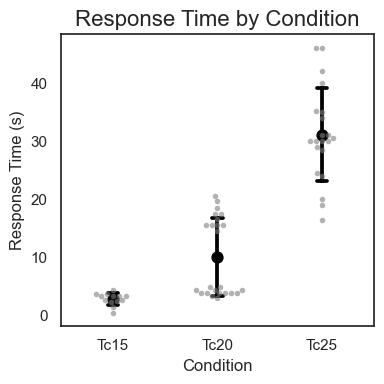


--- 1. Shapiro-Wilk Normality Test (Time) ---
Tc15: p-value = 0.1870
Tc20: p-value = 0.0001
Tc25: p-value = 0.3391

[Result]: Data violates normality. Running Non-Parametric Tests.

--- 2. Kruskal-Wallis Omnibus Test (Time) ---
p-value = 8.9178e-11

--- 3. Pairwise Mann-Whitney U Tests (Holm-Bonferroni Corrected) ---
Tc15 vs Tc20: p_adj = 8.7484e-06 (*)
Tc15 vs Tc25: p_adj = 2.7874e-06 (*)
Tc20 vs Tc25: p_adj = 9.9729e-08 (*)

 ANALYZING: Response Temp (Relative to frame 4650)



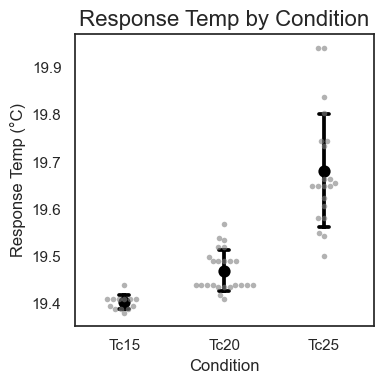


--- 1. Shapiro-Wilk Normality Test (Temp) ---
Tc15: p-value = 0.0482
Tc20: p-value = 0.0082
Tc25: p-value = 0.0708

[Result]: Data violates normality. Running Non-Parametric Tests.

--- 2. Kruskal-Wallis Omnibus Test (Temp) ---
p-value = 5.2555e-11

--- 3. Pairwise Mann-Whitney U Tests (Holm-Bonferroni Corrected) ---
Tc15 vs Tc20: p_adj = 3.7983e-06 (*)
Tc15 vs Tc25: p_adj = 2.6015e-06 (*)
Tc20 vs Tc25: p_adj = 7.0013e-08 (*)


In [14]:
# =========================================================
# HOW TO USE IT
# =========================================================
#  Comparing 3 Tc: 15, 20, 25  ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
compare_three = {
    'Tc15': (Tc15, Tc15frames),
    'Tc20': (Tc20, Tc20frames),
    'Tc25': (Tc25, Tc25frames)
}
#saveFigtime = "C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/VR_Naturalistic_with_Downshift_Stim/pt1_CompTime.svg"
#saveFigtemp = "C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/VR_Naturalistic_with_Downshift_Stim/pt1_CompTemp.svg"
saveFigtime = None
saveFigtemp = None
plot_and_analyze_metric(compare_three, metric='Time', start_frame=4650, saveFig=saveFigtime)
plot_and_analyze_metric(compare_three, metric='Temp', start_frame=4650, saveFig=saveFigtemp)

### Mid Region ~20C

In [15]:
st_frame = 6950
Tc20_DOWN3derivs, Tc20_DOWN3frames, Tc20_DOWN3times = find_AFD_deriv_and_response_thresh(Tc20_DOWN3, threshold = 0.01, start_frame = st_frame)
Tc25derivs, Tc25frames, Tc25times = find_AFD_deriv_and_response_thresh(Tc25, threshold = 0.01, start_frame = st_frame)
Tc20derivs, Tc20frames, Tc20times = find_AFD_deriv_and_response_thresh(Tc20, threshold = 0.01, start_frame = st_frame)
Tc15derivs, Tc15frames, Tc15times = find_AFD_deriv_and_response_thresh(Tc15, threshold = 0.01, start_frame = st_frame)


 ANALYZING: Response Time (Relative to frame 6950)



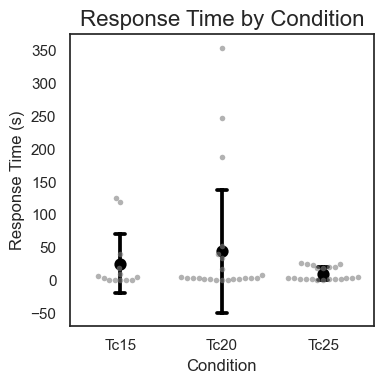


--- 1. Shapiro-Wilk Normality Test (Time) ---
Tc15: p-value = 0.0001
Tc20: p-value = 0.0000
Tc25: p-value = 0.0002

[Result]: Data violates normality. Running Non-Parametric Tests.

--- 2. Kruskal-Wallis Omnibus Test (Time) ---
p-value = 9.4913e-01

 ANALYZING: Response Temp (Relative to frame 6950)



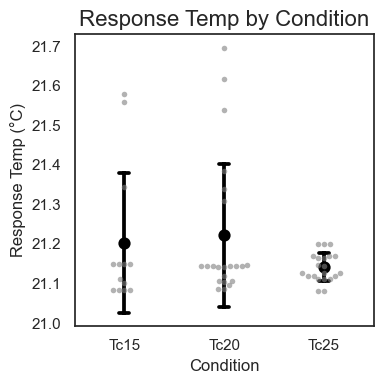


--- 1. Shapiro-Wilk Normality Test (Temp) ---
Tc15: p-value = 0.0003
Tc20: p-value = 0.0000
Tc25: p-value = 0.1493

[Result]: Data violates normality. Running Non-Parametric Tests.

--- 2. Kruskal-Wallis Omnibus Test (Temp) ---
p-value = 8.4182e-01


In [16]:
#  Comparing all 4 ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
compare_all = {
    'Tc15': (Tc15, Tc15frames),
    'Tc20': (Tc20, Tc20frames),
    'Tc25': (Tc25, Tc25frames),
    'Tc20 Down 3': (Tc20_DOWN3, Tc20_DOWN3frames)
}
#plot_and_analyze_metric(compare_all, metric='Time')
#plot_and_analyze_metric(compare_all, metric='Temp')

#  Comparing 3 Tc: 15, 20, 25  ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
compare_three = {
    'Tc15': (Tc15, Tc15frames),
    'Tc20': (Tc20, Tc20frames),
    'Tc25': (Tc25, Tc25frames)
}
st_frame = 6950
#saveFigtime = "C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/VR_Naturalistic_with_Downshift_Stim/pt2_CompTime.svg"
#saveFigtemp = "C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/VR_Naturalistic_with_Downshift_Stim/pt2_CompTemp.svg"
saveFigtime = None
saveFigtemp = None
plot_and_analyze_metric(compare_three, metric='Time', start_frame=st_frame, saveFig=saveFigtime)
plot_and_analyze_metric(compare_three, metric='Temp', start_frame=st_frame, saveFig=saveFigtemp)



# SineUpramp Downshift

In [12]:
## JB convert times from metadata to elapsed time formula

def extract_frameTimes_from_metadata(metadata_filename):
    frameTimes = []
    
    with open(metadata_filename) as f:
        metadata = json.load(f)
    f.close()
    
    if int(metadata['Summary']['MicroManagerVersion'][0]) == 1:
        print('MicroManager v1')
        hour = int(metadata['FrameKey-0-0-0']['Time'][11:13])
        minute = int(metadata['FrameKey-0-0-0']['Time'][14:16])
        second = int(metadata['FrameKey-0-0-0']['Time'][17:19])
        start_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)-int(metadata['FrameKey-0-0-0']['ElapsedTime-ms'])
    elif int(metadata['Summary']['MicroManagerVersion'][0]) > 1:
        print('MicroManager v2 or greater')
        hour = int(metadata['Summary']['StartTime'][11:13])
        minute = int(metadata['Summary']['StartTime'][14:16])
        second = int(metadata['Summary']['StartTime'][17:19])
        start_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)+int(metadata['Summary']['StartTime'][20:23])

    for i in range(len(metadata.keys())-1):
        frame_name = "FrameKey-"+str(i)+"-0-0"
        #print(frame_name, start_time + int(metadata[frame_name]['ElapsedTime-ms']))
        frameTimes.append(start_time + int(metadata[frame_name]['ElapsedTime-ms']))
            
    return frameTimes

def extract_temps_times_from_metadata(stim_filename):
    Stim_data = {}
    Stim_data['Temp'] = []
    Stim_data['Time'] = []
    with open(stim_filename, "r") as stim:
        if '/' in stim_filename:
            stim_filename = stim_filename.split('/')[-1]
            
        rep_to_time = stim_filename.split(".txt")[0].split("_")
        hour = int(rep_to_time[1][0]+rep_to_time[1][1])
        minute = int(rep_to_time[1][2]+rep_to_time[1][3])
        #second = int(rep_to_time[1][4]+rep_to_time[1][5])
        #ms = int(rep_to_time[2])
        #starting_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)+ms
        hour_min = (hour*60*60*1000)+(minute*60*1000)

        elapsed_time_check = 0
        elapsed_min = 0
        for line in stim:
            #print(line
            pieces = line.split("\t")
            if len(pieces) < 2 or len(pieces) > 4:
                continue
            else:
                Stim_data['Temp'].append(float(pieces[0]))

                sec = int(pieces[3].split(".")[0])
                ms = int(pieces[3].split(".")[1])
                elapsed_time = (elapsed_min*60*1000)+(sec*1000)+ms
                
                if (hour_min+elapsed_time) >= 86400000:
                    midnight_crossing = hour_min+elapsed_time
                    elapsed_time = midnight_crossing - 86400000
                    elapsed_time_check = -1
                    hour_min = 0
                    elapsed_min = 0

                if elapsed_time > elapsed_time_check:
                    Stim_data['Time'].append(hour_min+elapsed_time)
                    elapsed_time_check = elapsed_time
                elif elapsed_time <= elapsed_time_check:
                    elapsed_min += 1
                    elapsed_time = (elapsed_min*60*1000)+(sec*1000)+ms
                    Stim_data['Time'].append(hour_min+elapsed_time)
                    elapsed_time_check = elapsed_time
                else:
                    print('issue, something wrong')
    stim.close()
    return Stim_data

def align_Ca_to_stim(GCaMP_array, RFP_array, frameTimes, Stim):
    Stim_aligned_data = {}
    Stim_aligned_data['GCaMP'] = np.zeros((len(GCaMP_array),len(Stim['Time'])))
    Stim_aligned_data['RFP'] = np.zeros((len(RFP_array),len(Stim['Time'])))
    Stim_aligned_data['Time'] = []
    Stim_aligned_data['Temp'] = Stim['Temp']
    check = 1
    midnight_checker = 0
    for i in range(len(Stim['Time'])):
        if Stim['Time'][i-1] > 86340000 and Stim['Time'][i] < 60000 and midnight_checker == 0:
            Stim_aligned_data['Time'].append(Stim['Time'][i]+(86400000-Stim['Time'][0]))
            midnight_checker = 1
        elif midnight_checker == 1: 
            Stim_aligned_data['Time'].append(Stim['Time'][i]+(86400000-Stim['Time'][0]))
        else:
            Stim_aligned_data['Time'].append(Stim['Time'][i]-Stim['Time'][0])
        if Stim['Time'][i] > max(frameTimes):
            for j in range(len(GCaMP_array)):
                Stim_aligned_data['GCaMP'][j,i] = GCaMP_array[j,(len(GCaMP_array[j,:])-1)]
                Stim_aligned_data['RFP'][j,i] = RFP_array[j,(len(RFP_array[j,:])-1)]
            print('missed end')
        elif Stim['Time'][i] < min(frameTimes):
            for j in range(len(GCaMP_array)):
                Stim_aligned_data['GCaMP'][j,i] = GCaMP_array[j,0]
                Stim_aligned_data['RFP'][j,i] = RFP_array[j,0]
            print('missed start')
        else:
            for j in range(check, len(frameTimes)):
                if frameTimes[j-1] < Stim['Time'][i] <= frameTimes[j]:
                    for k in range(len(GCaMP_array)):
                        Stim_aligned_data['GCaMP'][k,i] = GCaMP_array[k,j]
                        Stim_aligned_data['RFP'][k,i] = RFP_array[k,j]
                    check = j
                    break
    return Stim_aligned_data

def ratio_and_scale(GCaMP_Array, RFP_Array, RFP_check=True):
    Ratio = np.zeros(np.shape(GCaMP_Array))
    Scaled = np.zeros(np.shape(GCaMP_Array))
    Delta = np.zeros(np.shape(GCaMP_Array))
    
    if RFP_check == True:
        for i in range(len(GCaMP_Array)):
            for j in range(len(GCaMP_Array[i,:])):
                Ratio[i,j] = GCaMP_Array[i,j]/RFP_Array[i,j]
            min_rat = min(Ratio[i,:])
            for j in range(len(Ratio[i,:])):
                Delta[i,j] = (Ratio[i,j] - min_rat)/float(min_rat)
            Scaled[i,:] = minmax_scale(Ratio[i,:], feature_range=(0, 1))
    elif RFP_check == False:
        for i in range(len(GCaMP_Array)):
            Scaled[i,:] = minmax_scale(GCaMP_Array[i,:], feature_range=(0, 1))
            min_gcamp = min(GCaMP_Array[i,:])
            for j in range(len(GCaMP_Array[i,:])):
                Delta[i,j] = (GCaMP_Array[i,j] - min_gcamp)/float(min_gcamp)
    else:
        print('issue Scaling')
        
    return Delta, Scaled

def find_temp_transition(Stim_aligned_data, start_search, temp_thresh):
    for i in reversed(range(start_search)):
        if Stim_aligned_data['Temp'][i]>=temp_thresh:
            start_index = i
            break
    #print(start_index)
    return start_index

def segment_data(Stim_aligned_data, start_index, stop_index, AIY=False):
    Segmented_data = {}
    Segmented_data['GCaMP'] = Stim_aligned_data['GCaMP'][:,start_index:stop_index]
    Segmented_data['RFP'] = Stim_aligned_data['RFP'][:,start_index:stop_index]
    Segmented_data['Scaled'] = Stim_aligned_data['Scaled'][:,start_index:stop_index]
    Segmented_data['Time'] = []
    for i in range(len(Stim_aligned_data['Time'][start_index:stop_index])):
        Segmented_data['Time'].append(Stim_aligned_data['Time'][start_index+i]-Stim_aligned_data['Time'][start_index])
    Segmented_data['Temp'] = Stim_aligned_data['Temp'][start_index:stop_index]
    
    if AIY == True:
        Segmented_data['Resp_Rate'] = Stim_aligned_data['Resp_Rate'][:,start_index:stop_index]
        Segmented_data['Resp'] = Stim_aligned_data['Resp'][:,start_index:stop_index]
    
    return Segmented_data

def combine_segments_calc_stats(Segment_list, AIY=False):
    Combined_data = {}
    Combined_data['GCaMP'] = np.concatenate([Seg_dict['GCaMP'] for Seg_dict in Segment_list], axis=0)
    Combined_data['RFP'] = np.concatenate([Seg_dict['RFP'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Scaled'] = np.concatenate([Seg_dict['Scaled'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Delta'] = np.concatenate([Seg_dict['Delta'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Mean'] = []
    Combined_data['Std_high'] = []
    Combined_data['Std_low'] = []
    Combined_data['Mean_Delta'] = []
    Combined_data['Std_high_Delta'] = []
    Combined_data['Std_low_Delta'] = []
    for i in range(len(Combined_data['Scaled'][0,:])):
        Combined_data['Mean'].append(np.mean(Combined_data['Scaled'][:,i]))
        Combined_data['Std_high'].append(np.mean(Combined_data['Scaled'][:,i])+tstd(Combined_data['Scaled'][:,i]))
        Combined_data['Std_low'].append(np.mean(Combined_data['Scaled'][:,i])-tstd(Combined_data['Scaled'][:,i]))
        Combined_data['Mean_Delta'].append(np.mean(Combined_data['Delta'][:,i]))
        Combined_data['Std_high_Delta'].append(np.mean(Combined_data['Delta'][:,i])+tstd(Combined_data['Delta'][:,i]))
        Combined_data['Std_low_Delta'].append(np.mean(Combined_data['Delta'][:,i])-tstd(Combined_data['Delta'][:,i]))
    Combined_data['Time'] = []
    Combined_data['Temp'] = []
    for i in range(len(Segment_list[0]['Time'])):
        time_total_dum = 0
        time_count_dum = 0
        temp_total_dum = 0
        temp_count_dum = 0
        for j in range(len(Segment_list)):
            time_total_dum += Segment_list[j]['Time'][i]*len(Segment_list[j]['GCaMP'])
            time_count_dum += len(Segment_list[j]['GCaMP'])
            temp_total_dum += Segment_list[j]['Temp'][i]*len(Segment_list[j]['GCaMP'])
            temp_count_dum += len(Segment_list[j]['GCaMP'])
        Combined_data['Time'].append(time_total_dum/(time_count_dum*1000))
        Combined_data['Temp'].append(temp_total_dum/temp_count_dum)
        
    if AIY == True:
        Combined_data['Resp'] = np.concatenate([Seg_dict['Resp'] for Seg_dict in Segment_list], axis=0)
        Combined_data['Resp_Rate'] = np.concatenate([Seg_dict['Resp_Rate'] for Seg_dict in Segment_list], axis=0)
        Combined_data['Mean_Resp_Rate'] = []
        for i in range(len(Combined_data['Resp_Rate'][0,:])):
            Combined_data['Mean_Resp_Rate'].append(np.mean(Combined_data['Resp_Rate'][:,i]))
            
    return Combined_data

def load_GCaMP_RFP_meta_stim(Rep_list, stim_list, cell='None', RFP_check=True, subcell='None'):
    # Possible kwargs: cell = '
    Aligned_data_list = []
    for i in range(len(Rep_list)):
        Rep_name = Rep_list[i]
        stim_name = stim_list[i]
        print(Rep_name)
        if cell != 'None' and subcell != 'None':
            GCaMP = np.transpose(np.array(pd.read_csv(Rep_name+'_'+cell+'_'+subcell+'_Results.csv', header=None)))
            if RFP_check==True:
                RFP = np.transpose(np.array(pd.read_csv(Rep_name+'_'+cell+'_'+subcell+'_Results_RFP.csv', header=None)))
            elif RFP_check==False:
                RFP = np.zeros(np.shape(GCaMP))
        elif cell != 'None':
            GCaMP = np.transpose(np.array(pd.read_csv(Rep_name+'_'+cell+'_Results.csv', header=None)))
            if RFP_check==True:
                RFP = np.transpose(np.array(pd.read_csv(Rep_name+'_'+cell+'_Results_RFP.csv', header=None)))
            elif RFP_check==False:
                RFP = np.zeros(np.shape(GCaMP))
        else:
            GCaMP = np.transpose(np.array(pd.read_csv(Rep_name+'_Results.csv', header=None)))
            if RFP_check==True:
                RFP = np.transpose(np.array(pd.read_csv(Rep_name+'_Results_RFP.csv', header=None)))
            elif RFP_check==False:
                RFP = np.zeros(np.shape(GCaMP))

        frameTimes = extract_frameTimes_from_metadata(Rep_name+'_MMStack_Pos0_metadata.txt')
        #print(frameTimes[0:10]
        Stim = extract_temps_times_from_metadata(stim_name+'.txt')
        #print(Stim['Time'][0:10]

        Aligned_data = align_Ca_to_stim(GCaMP, RFP, frameTimes, Stim)
        Aligned_data['Delta'], Aligned_data['Scaled'] = ratio_and_scale(Aligned_data['GCaMP'], Aligned_data['RFP'], RFP_check=RFP_check)

        if cell == 'AIY':
            Aligned_data['Resp'], Aligned_data['Resp_Rate'] = calc_AIY_responses(Aligned_data['Scaled'], threshold = 0.05, window = 300)

        if cell == 'AIY_Paired':
            Aligned_data['Resp'], Aligned_data['Resp_Rate'] = calc_AIY_responses(Aligned_data['Scaled'], threshold = 0.05, window = 300)
        
        Aligned_data_list.append(Aligned_data)
        print('Done')
        
    if cell == 'AFD' or cell == 'None':
        Aligned_data_Combined = combine_segments_calc_stats(Aligned_data_list)
        Aligned_data_Combined['Deriv'], Aligned_data_Combined['Response_frame'], Aligned_data_Combined['Response_temp'] = find_AFD_deriv_and_response_thresh(Aligned_data_Combined)
    elif cell == 'AIY':
        Aligned_data_Combined = combine_segments_calc_stats(Aligned_data_list, AIY=True)
        
    return Aligned_data_Combined

def calc_AIY_responses(Scaled_data, threshold = 0.05, window = 300, back=True):
    AIY_Deriv = np.zeros(np.shape(Scaled_data))
    AIY_Response = np.zeros(np.shape(Scaled_data))
    AIY_Resp_Rate = np.zeros(np.shape(Scaled_data))
        
        
    for i in range(len(Scaled_data)):
        AIY_Deriv[i,1:] = np.diff(Scaled_data[i,:])

        check = 0
        for j in range(len(AIY_Deriv[i,:])):
            if AIY_Deriv[i,j] > threshold and check == 0:
                AIY_Response[i,j] = 1
                check = 1
            elif AIY_Deriv[i,j] < threshold and check == 1:
                check = 0
            else:
                continue

        for j in range(len(AIY_Response[i,:])):
            if back == True:
                if j-(2*window) < 0:
                    #Tc20_Combined['AIY'][key]['Resp_Rate'][i,j] = np.sum(Tc20_Combined['AIY'][key]['Response'][i,0:j])*60/float(j/10)
                    AIY_Resp_Rate[i,j] = np.nan
                else:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-(2*window):j])
            else:
                if j-window < 0:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,0:j+window])*60/float((j+window)*60/10)
                elif j+window > len(AIY_Response[i,:]):
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-window:])
                else:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-window:j+window])

        #Tc20_Combined['AIY'][key]['Mean_Resp_Rate'] = []
        #for i in range(len(Tc20_Combined['AIY'][key]['Resp_Rate'][0,:])):
        #    Tc20_Combined['AIY'][key]['Mean_Resp_Rate'].append(np.mean(Tc20_Combined['AIY'][key]['Resp_Rate'][:,i]))
            
    return AIY_Response, AIY_Resp_Rate

def find_AFD_deriv_and_response_thresh(AFD_data, threshold = 0.01, start_frame = 600):
    Deriv = [0]
    Deriv.extend(list(np.diff(AFD_data['Mean'])))
    for i in range(len(Deriv[start_frame:])):
        if Deriv[start_frame+i] > threshold:
            Response_frame = start_frame+i
            Response_temp = AFD_data['Temp'][Response_frame]
            break
    return Deriv, Response_frame, Response_temp

In [13]:
pref = 'Temp_Downshift_25_15/Data/'
Min0_meta = [pref + '051021_3055_12deghold_Sinusoid_Ramp_Tc25_0min_A_1', pref + '051121_3055_12deghold_Sinusoid_Ramp_Tc25_0min_A_1']
Min0_stim = [pref + '051021_171757_216', pref + '051121_214436_704']

AFD_Min0 = load_GCaMP_RFP_meta_stim(Min0_meta, Min0_stim)

Temp_Downshift_25_15/Data/051021_3055_12deghold_Sinusoid_Ramp_Tc25_0min_A_1
MicroManager v1
Done
Temp_Downshift_25_15/Data/051121_3055_12deghold_Sinusoid_Ramp_Tc25_0min_A_1
MicroManager v1
Done


In [14]:
pref = 'Temp_Downshift_25_15/Data/'

Min60_meta = [pref + '051021_3055_12deghold_Sinusoid_Ramp_Tc25_60min_A_1', pref + '051121_3055_12deghold_Sinusoid_Ramp_Tc25_60min_A_1']
Min60_stim = [pref + '051021_204502_192', pref + '051121_132353_636']
AFD_Min60 = load_GCaMP_RFP_meta_stim(Min60_meta, Min60_stim)
    
Min240_meta = [pref + '051121_3055_12deghold_Sinusoid_Ramp_Tc25_240min_A_1']
Min240_stim = [pref + '051121_210703_363']

AFD_Min240 = load_GCaMP_RFP_meta_stim(Min240_meta, Min240_stim)

Tc15_meta = [pref + '050521_3055_12deghold_Sinusoid_Ramp_Tc15_B_1']
Tc15_stim = [pref + '050521_175328_753']

AFD_Tc15 = load_GCaMP_RFP_meta_stim(Tc15_meta, Tc15_stim)


Temp_Downshift_25_15/Data/051021_3055_12deghold_Sinusoid_Ramp_Tc25_60min_A_1
MicroManager v1
Done
Temp_Downshift_25_15/Data/051121_3055_12deghold_Sinusoid_Ramp_Tc25_60min_A_1
MicroManager v1
Done
Temp_Downshift_25_15/Data/051121_3055_12deghold_Sinusoid_Ramp_Tc25_240min_A_1
MicroManager v1
Done
Temp_Downshift_25_15/Data/050521_3055_12deghold_Sinusoid_Ramp_Tc15_B_1
MicroManager v1
Done


<Figure size 640x480 with 0 Axes>

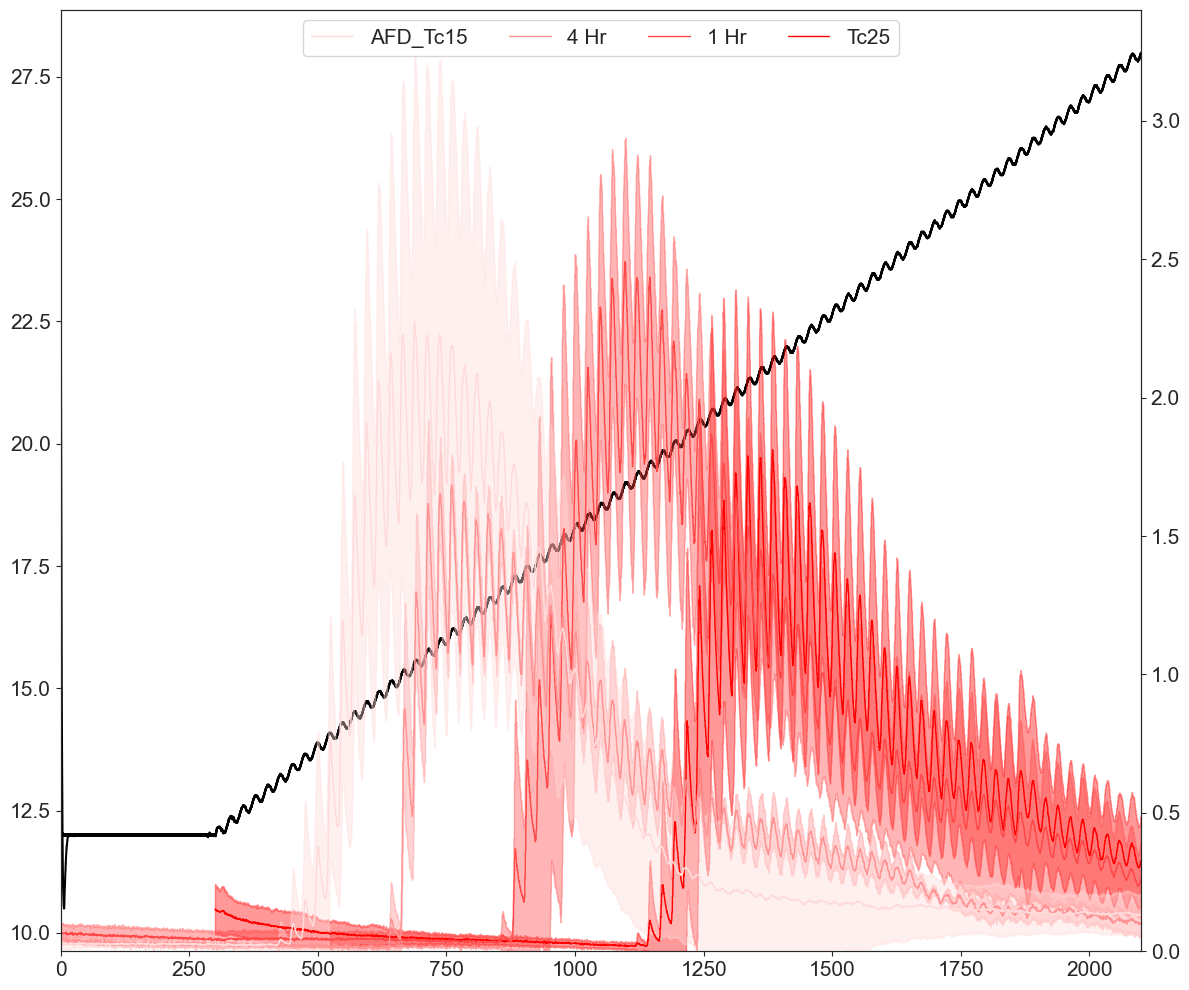

In [14]:
# No min-max scaling
plt.clf()
fig = plt.subplots(nrows=1,ncols=1,figsize=(12,10))

ax1 = plt.subplot(1,1,1)
ax1.plot(AFD_Tc15['Time'], AFD_Tc15['Temp'], 'k')
ax1.plot(AFD_Min240['Time'], AFD_Min240['Temp'], 'k')
ax1.plot(AFD_Min60['Time'], AFD_Min60['Temp'], 'k')
ax1.plot(AFD_Min0['Time'], AFD_Min0['Temp'], 'k')

ax1.set_xlim(min(AFD_Min240['Time']),max(AFD_Min240['Time']))
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax2 = ax1.twinx()
color=iter(cm.bwr_r(np.linspace(0,1,8)))
ax2.plot(AFD_Min0['Time'][3000:], AFD_Min0['Mean_Delta'][3000:], c=next(color), lw=1, label='Tc25')
ax2.plot(AFD_Min60['Time'], AFD_Min60['Mean_Delta'], c=next(color), lw=1, label='1 Hr')
ax2.plot(AFD_Min240['Time'], AFD_Min240['Mean_Delta'], c=next(color), lw=1, label='4 Hr')
ax2.plot(AFD_Tc15['Time'], AFD_Tc15['Mean_Delta'], c=next(color), lw=1, label='AFD_Tc15')
handlesyep, labelsyep = ax2.get_legend_handles_labels()

ax2.legend(handles = reversed(handlesyep), labels=reversed(labelsyep), fontsize = 15, loc='upper center', ncol=7)
color=iter(cm.bwr_r(np.linspace(0,1,8)))
ax2.fill_between(AFD_Min0['Time'][3000:], AFD_Min0['Std_low_Delta'][3000:], AFD_Min0['Std_high_Delta'][3000:], color=next(color), alpha=0.4, lw=1)
ax2.fill_between(AFD_Min60['Time'], AFD_Min60['Std_low_Delta'], AFD_Min60['Std_high_Delta'], color=next(color), alpha=0.4, lw=1)
ax2.fill_between(AFD_Min240['Time'], AFD_Min240['Std_low_Delta'], AFD_Min240['Std_high_Delta'], color=next(color), alpha=0.4, lw=1)
ax2.fill_between(AFD_Tc15['Time'], AFD_Tc15['Std_low_Delta'], AFD_Tc15['Std_high_Delta'], color=next(color), alpha=0.4, lw=1)

ax2.set_ylim(0,3.4)
ax2.set_xlim(min(AFD_Min240['Time']),max(AFD_Min240['Time']))
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.tight_layout()

#lt.savefig('TcDownShiftExpt.png', dpi=600, bbox_inches='tight')
#plt.savefig('TcDownShiftExpt_NoMinMax.svg', dpi=600, bbox_inches='tight')
plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

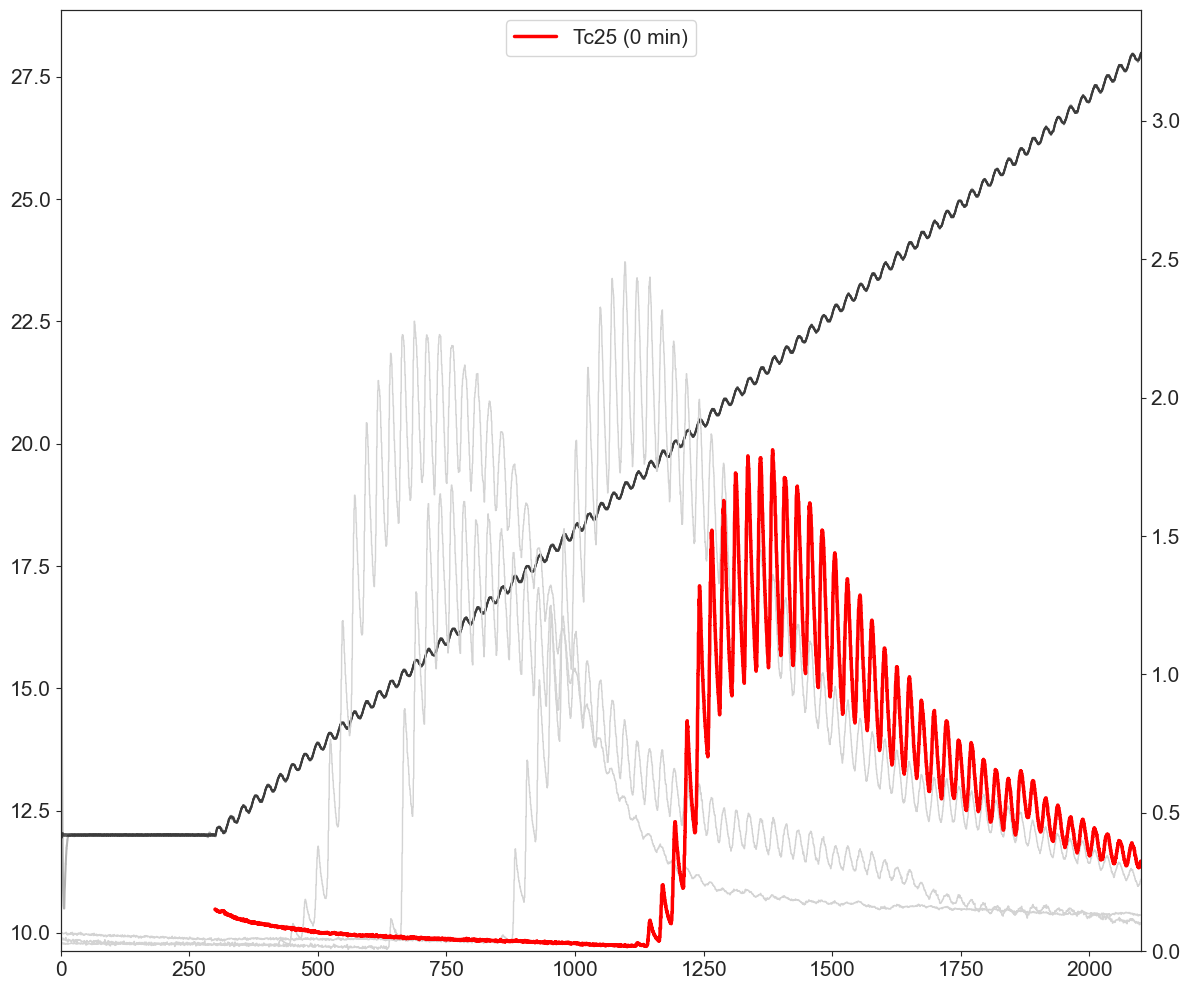

<Figure size 640x480 with 0 Axes>

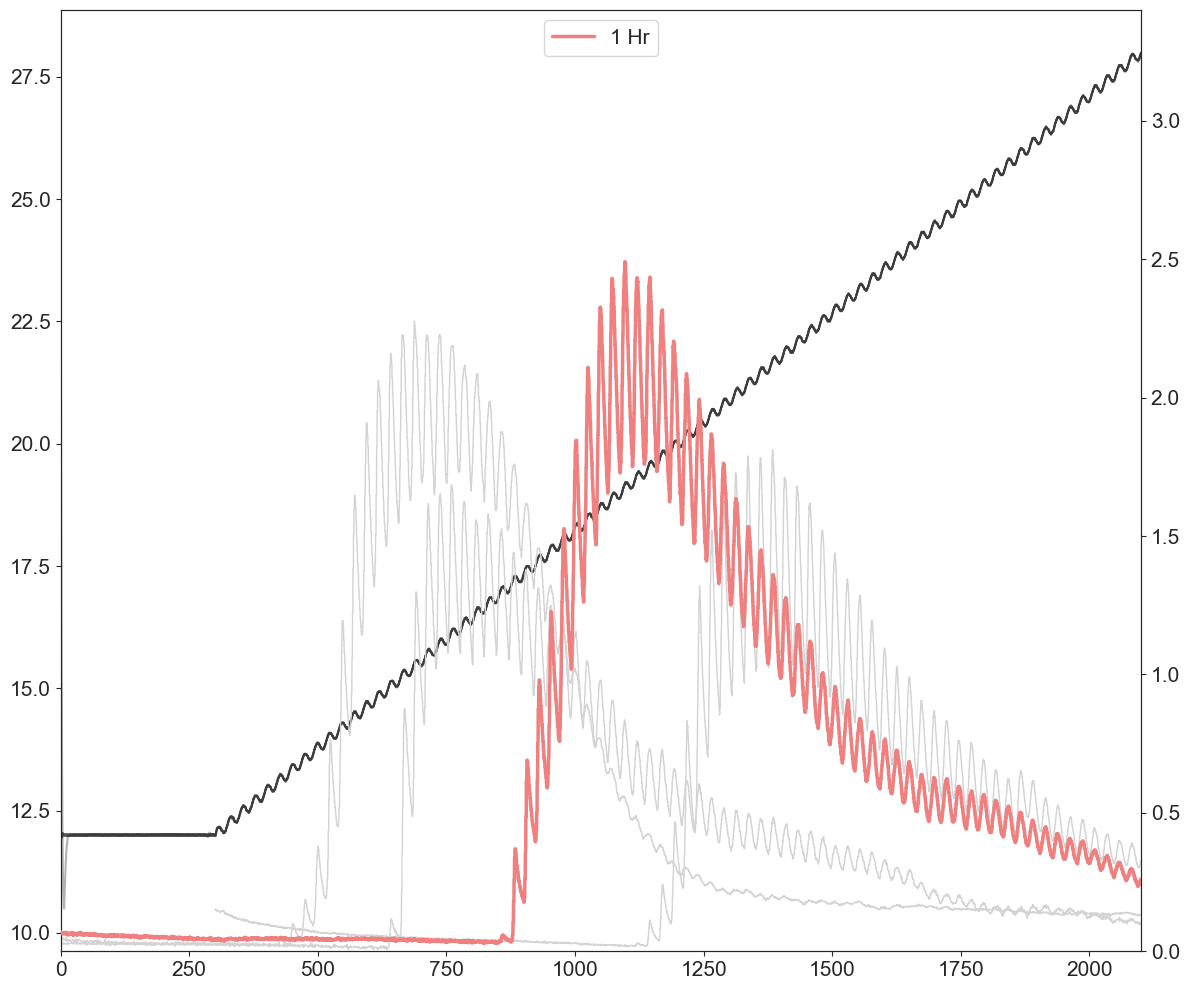

<Figure size 640x480 with 0 Axes>

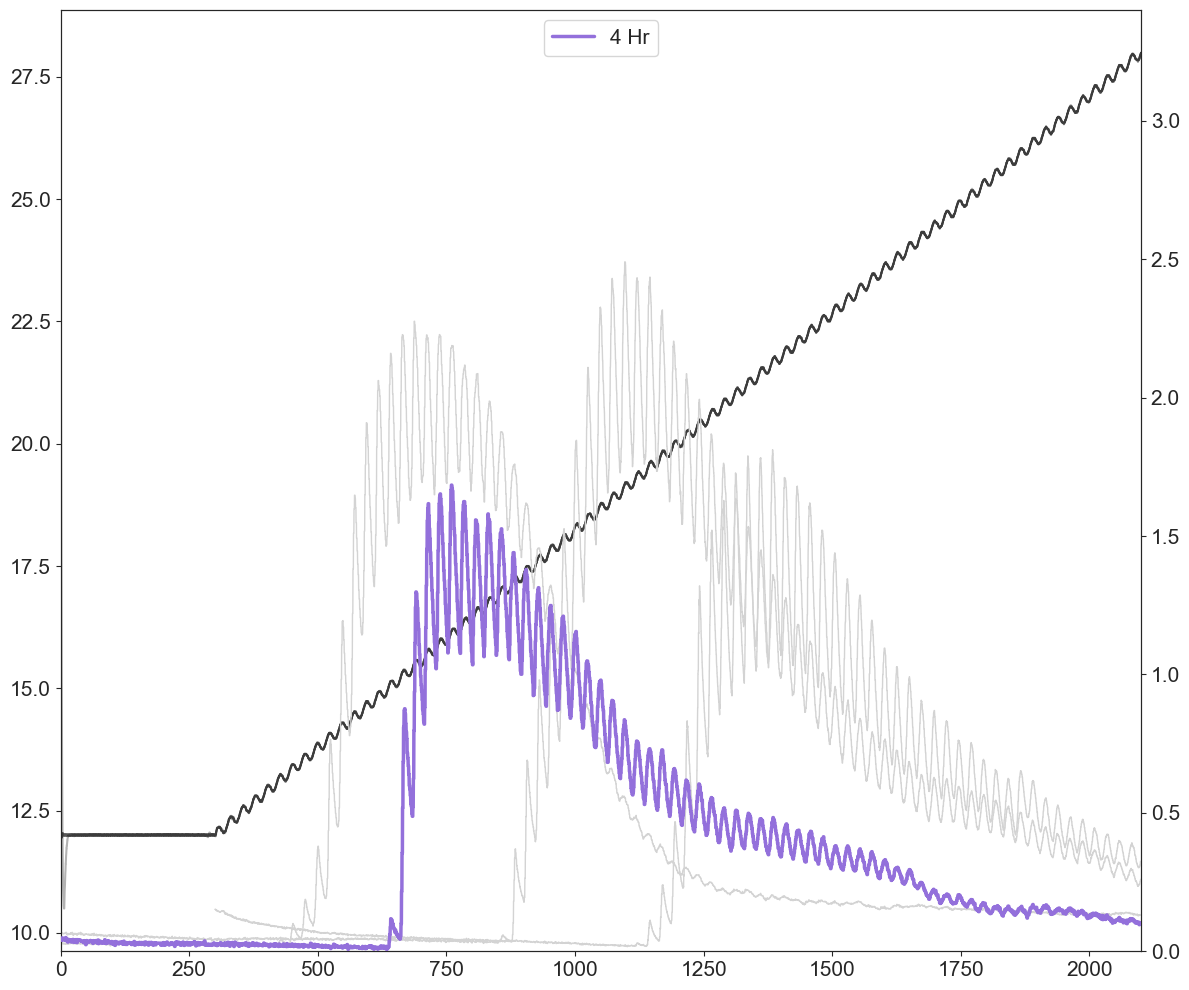

<Figure size 640x480 with 0 Axes>

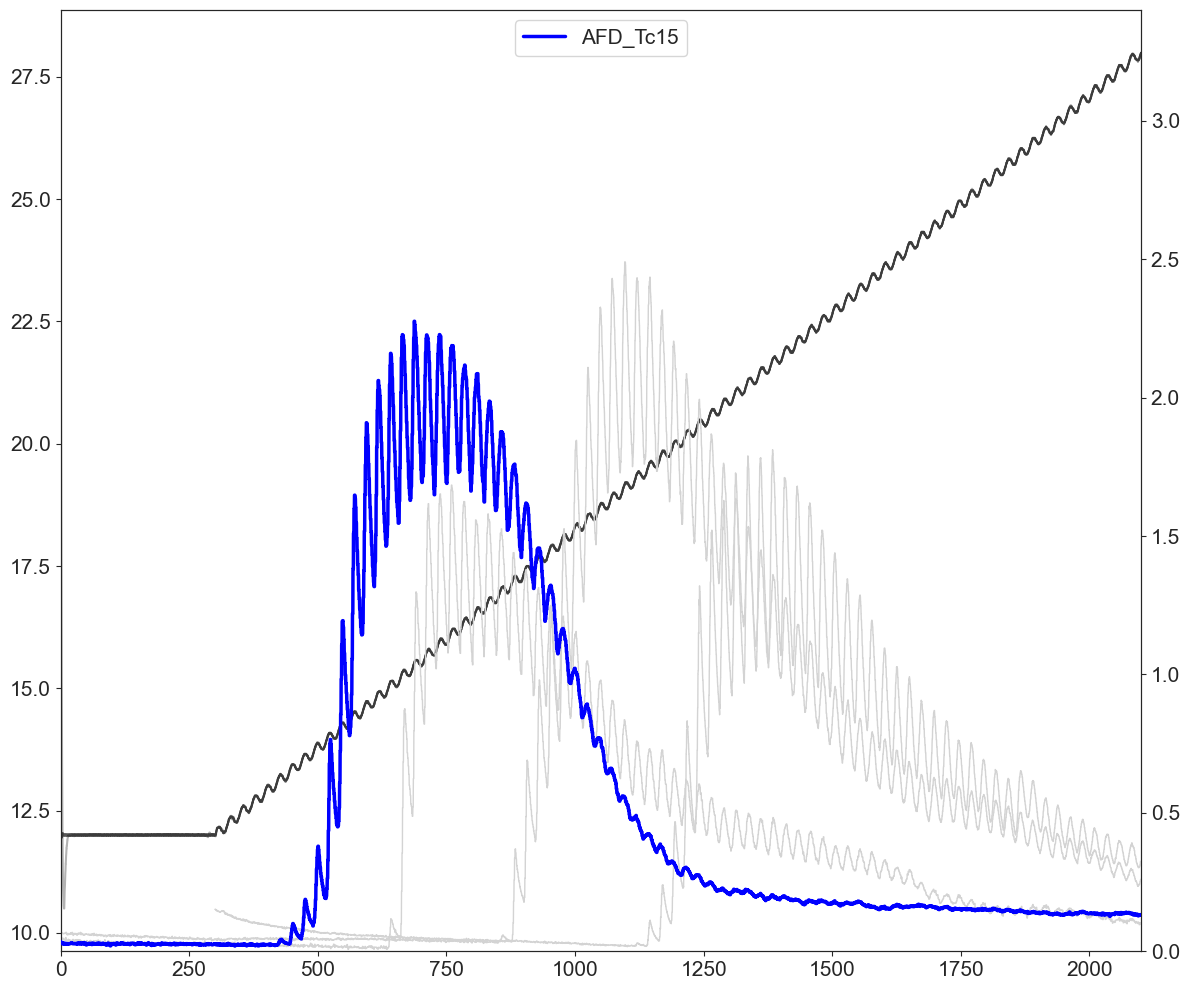

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the datasets and their highlighted styling
groups = [
    {'data': AFD_Min0, 'color': 'red', 'label': 'Tc25 (0 min)', 'slice': slice(3000, None)},
    {'data': AFD_Min60, 'color': 'lightcoral', 'label': '1 Hr', 'slice': slice(None)},
    {'data': AFD_Min240, 'color': 'mediumpurple', 'label': '4 Hr', 'slice': slice(None)},
    {'data': AFD_Tc15, 'color': 'blue', 'label': 'AFD_Tc15', 'slice': slice(None)}
]

for i, highlight_group in enumerate(groups):
    plt.clf()
    fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(12, 10))
    
    # --- Axis 1: Temperature Profile ---
    # Plotting temperature in black for all
    for g in groups:
        ax1.plot(g['data']['Time'], g['data']['Temp'], 'k', alpha=0.3)
    
    ax1.set_xlim(min(AFD_Min240['Time']), max(AFD_Min240['Time']))
    ax1.tick_params(axis='both', which='major', labelsize=15)

    # --- Axis 2: Calcium Dynamics (Mean Delta) ---
    ax2 = ax1.twinx()
    
    # 1. Plot background groups in gray (No error bars)
    for background_group in groups:
        d = background_group['data']
        s = background_group['slice']
        ax2.plot(d['Time'][s], d['Mean_Delta'][s], color='lightgray', lw=1, zorder=1)

    # 2. Plot the highlighted group (With color and error bars)
    target = highlight_group['data']
    t_color = highlight_group['color']
    t_label = highlight_group['label']
    t_slice = highlight_group['slice']
    
    # Plot mean trace
    ax2.plot(target['Time'][t_slice], target['Mean_Delta'][t_slice], 
             color=t_color, lw=2.5, label=t_label, zorder=3)


    # Styling and limits
    ax2.set_ylim(0, 3.4)
    ax2.set_xlim(min(AFD_Min240['Time']), max(AFD_Min240['Time']))
    ax2.legend(fontsize=15, loc='upper center')
    ax2.tick_params(axis='both', which='major', labelsize=15)
    
    plt.tight_layout()
    
    # Optional: Save each plot uniquely
    # plt.savefig(f'Highlight_{t_label.replace(" ", "_")}.png', dpi=300)
    
    plt.show()
    plt.close()

# Upshift

In [11]:
def extract_frameTimes_from_metadata(metadata_filename):
    frameTimes = []
    
    with open(metadata_filename) as f:
        metadata = json.load(f)
    f.close()
    
    if int(metadata['Summary']['MicroManagerVersion'][0]) == 1:
        print('MicroManager v1')
        hour = int(metadata['FrameKey-0-0-0']['Time'][11:13])
        minute = int(metadata['FrameKey-0-0-0']['Time'][14:16])
        second = int(metadata['FrameKey-0-0-0']['Time'][17:19])
        start_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)-int(metadata['FrameKey-0-0-0']['ElapsedTime-ms'])
    elif int(metadata['Summary']['MicroManagerVersion'][0]) > 1:
        print('MicroManager v2 or greater')
        hour = int(metadata['Summary']['StartTime'][11:13])
        minute = int(metadata['Summary']['StartTime'][14:16])
        second = int(metadata['Summary']['StartTime'][17:19])
        start_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)+int(metadata['Summary']['StartTime'][20:23])

    for i in range(len(metadata.keys())-1):
        frame_name = "FrameKey-"+str(i)+"-0-0"
        #print(frame_name, start_time + int(metadata[frame_name]['ElapsedTime-ms']))
        frameTimes.append(start_time + int(metadata[frame_name]['ElapsedTime-ms']))
            
    return frameTimes

def extract_temps_times_from_metadata(stim_filename):
    Stim_data = {}
    Stim_data['Temp'] = []
    Stim_data['Time'] = []
    with open(stim_filename, "r") as stim:
        if '/' in stim_filename:
            stim_filename = stim_filename.split('/')[-1]
            
        rep_to_time = stim_filename.split(".txt")[0].split("_")
        hour = int(rep_to_time[1][0]+rep_to_time[1][1])
        minute = int(rep_to_time[1][2]+rep_to_time[1][3])
        #second = int(rep_to_time[1][4]+rep_to_time[1][5])
        #ms = int(rep_to_time[2])
        #starting_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)+ms
        hour_min = (hour*60*60*1000)+(minute*60*1000)

        elapsed_time_check = 0
        elapsed_min = 0
        for line in stim:
            #print(line
            pieces = line.split("\t")
            if len(pieces) < 2 or len(pieces) > 4:
                continue
            else:
                Stim_data['Temp'].append(float(pieces[0]))

                sec = int(pieces[3].split(".")[0])
                ms = int(pieces[3].split(".")[1])
                elapsed_time = (elapsed_min*60*1000)+(sec*1000)+ms
                
                if (hour_min+elapsed_time) >= 86400000:
                    midnight_crossing = hour_min+elapsed_time
                    elapsed_time = midnight_crossing - 86400000
                    elapsed_time_check = -1
                    hour_min = 0
                    elapsed_min = 0

                if elapsed_time > elapsed_time_check:
                    Stim_data['Time'].append(hour_min+elapsed_time)
                    elapsed_time_check = elapsed_time
                elif elapsed_time <= elapsed_time_check:
                    elapsed_min += 1
                    elapsed_time = (elapsed_min*60*1000)+(sec*1000)+ms
                    Stim_data['Time'].append(hour_min+elapsed_time)
                    elapsed_time_check = elapsed_time
                else:
                    print('issue, something wrong')
    stim.close()
    return Stim_data

def align_Ca_to_stim(GCaMP_array, RFP_array, frameTimes, Stim):
    Stim_aligned_data = {}
    Stim_aligned_data['GCaMP'] = np.zeros((len(GCaMP_array),len(Stim['Time'])))
    Stim_aligned_data['RFP'] = np.zeros((len(RFP_array),len(Stim['Time'])))
    Stim_aligned_data['Time'] = []
    Stim_aligned_data['Temp'] = Stim['Temp']
    check = 1
    midnight_checker = 0
    for i in range(len(Stim['Time'])):
        if Stim['Time'][i-1] > 86340000 and Stim['Time'][i] < 60000 and midnight_checker == 0:
            Stim_aligned_data['Time'].append(Stim['Time'][i]+(86400000-Stim['Time'][0]))
            midnight_checker = 1
        elif midnight_checker == 1: 
            Stim_aligned_data['Time'].append(Stim['Time'][i]+(86400000-Stim['Time'][0]))
        else:
            Stim_aligned_data['Time'].append(Stim['Time'][i]-Stim['Time'][0])
        if Stim['Time'][i] > max(frameTimes):
            for j in range(len(GCaMP_array)):
                Stim_aligned_data['GCaMP'][j,i] = GCaMP_array[j,(len(GCaMP_array[j,:])-1)]
                Stim_aligned_data['RFP'][j,i] = RFP_array[j,(len(RFP_array[j,:])-1)]
            print('missed end')
        elif Stim['Time'][i] < min(frameTimes):
            for j in range(len(GCaMP_array)):
                Stim_aligned_data['GCaMP'][j,i] = GCaMP_array[j,0]
                Stim_aligned_data['RFP'][j,i] = RFP_array[j,0]
            print('missed start')
        else:
            for j in range(check, len(frameTimes)):
                if frameTimes[j-1] < Stim['Time'][i] <= frameTimes[j]:
                    for k in range(len(GCaMP_array)):
                        Stim_aligned_data['GCaMP'][k,i] = GCaMP_array[k,j]
                        Stim_aligned_data['RFP'][k,i] = RFP_array[k,j]
                    check = j
                    break
    return Stim_aligned_data

def ratio_and_scale(GCaMP_Array, RFP_Array, RFP_check=True):
    Ratio = np.zeros(np.shape(GCaMP_Array))
    Scaled = np.zeros(np.shape(GCaMP_Array))
    Delta = np.zeros(np.shape(GCaMP_Array))
    
    if RFP_check == True:
        for i in range(len(GCaMP_Array)):
            for j in range(len(GCaMP_Array[i,:])):
                Ratio[i,j] = GCaMP_Array[i,j]/RFP_Array[i,j]
            min_rat = min(Ratio[i,:])
            for j in range(len(Ratio[i,:])):
                Delta[i,j] = (Ratio[i,j] - min_rat)/float(min_rat)
            Scaled[i,:] = minmax_scale(Ratio[i,:], feature_range=(0, 1))
    elif RFP_check == False:
        for i in range(len(GCaMP_Array)):
            Scaled[i,:] = minmax_scale(GCaMP_Array[i,:], feature_range=(0, 1))
            min_gcamp = min(GCaMP_Array[i,:])
            for j in range(len(GCaMP_Array[i,:])):
                Delta[i,j] = (GCaMP_Array[i,j] - min_gcamp)/float(min_gcamp)
    else:
        print('issue Scaling')
        
    return Ratio, Delta, Scaled

def find_temp_transition(Stim_aligned_data, start_search, temp_thresh):
    for i in reversed(range(start_search)):
        if Stim_aligned_data['Temp'][i]>=temp_thresh:
            start_index = i
            break
    #print(start_index)
    return start_index

def segment_data(Stim_aligned_data, start_index, stop_index, AIY=False):
    Segmented_data = {}
    Segmented_data['GCaMP'] = Stim_aligned_data['GCaMP'][:,start_index:stop_index]
    Segmented_data['RFP'] = Stim_aligned_data['RFP'][:,start_index:stop_index]
    Segmented_data['Scaled'] = Stim_aligned_data['Scaled'][:,start_index:stop_index]
    Segmented_data['Time'] = []
    for i in range(len(Stim_aligned_data['Time'][start_index:stop_index])):
        Segmented_data['Time'].append(Stim_aligned_data['Time'][start_index+i]-Stim_aligned_data['Time'][start_index])
    Segmented_data['Temp'] = Stim_aligned_data['Temp'][start_index:stop_index]
    
    if AIY == True:
        Segmented_data['Resp_Rate'] = Stim_aligned_data['Resp_Rate'][:,start_index:stop_index]
        Segmented_data['Resp'] = Stim_aligned_data['Resp'][:,start_index:stop_index]
    
    return Segmented_data

def combine_segments_calc_stats(Segment_list, AIY=False):
    Combined_data = {}
    Combined_data['GCaMP'] = np.concatenate([Seg_dict['GCaMP'] for Seg_dict in Segment_list], axis=0)
    Combined_data['RFP'] = np.concatenate([Seg_dict['RFP'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Scaled'] = np.concatenate([Seg_dict['Scaled'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Delta'] = np.concatenate([Seg_dict['Delta'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Ratio'] = np.concatenate([Seg_dict['Ratio'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Mean'] = []
    Combined_data['Std_high'] = []
    Combined_data['Std_low'] = []
    Combined_data['Mean_Delta'] = []
    Combined_data['Std_high_Delta'] = []
    Combined_data['Std_low_Delta'] = []
    Combined_data['Mean_Ratio'] = []
    Combined_data['Std_high_Ratio'] = []
    Combined_data['Std_low_Ratio'] = []
    for i in range(len(Combined_data['Scaled'][0,:])):
        Combined_data['Mean'].append(np.mean(Combined_data['Scaled'][:,i]))
        Combined_data['Std_high'].append(np.mean(Combined_data['Scaled'][:,i])+tstd(Combined_data['Scaled'][:,i]))
        Combined_data['Std_low'].append(np.mean(Combined_data['Scaled'][:,i])-tstd(Combined_data['Scaled'][:,i]))
        Combined_data['Mean_Delta'].append(np.mean(Combined_data['Delta'][:,i]))
        Combined_data['Std_high_Delta'].append(np.mean(Combined_data['Delta'][:,i])+tstd(Combined_data['Delta'][:,i]))
        Combined_data['Std_low_Delta'].append(np.mean(Combined_data['Delta'][:,i])-tstd(Combined_data['Delta'][:,i]))
        Combined_data['Mean_Ratio'].append(np.mean(Combined_data['Delta'][:,i]))
        Combined_data['Std_high_Ratio'].append(np.mean(Combined_data['Ratio'][:,i])+tstd(Combined_data['Ratio'][:,i]))
        Combined_data['Std_low_Ratio'].append(np.mean(Combined_data['Ratio'][:,i])-tstd(Combined_data['Ratio'][:,i]))
    Combined_data['Time'] = []
    Combined_data['Temp'] = []
    for i in range(len(Segment_list[0]['Time'])):
        time_total_dum = 0
        time_count_dum = 0
        temp_total_dum = 0
        temp_count_dum = 0
        for j in range(len(Segment_list)):
            time_total_dum += Segment_list[j]['Time'][i]*len(Segment_list[j]['GCaMP'])
            time_count_dum += len(Segment_list[j]['GCaMP'])
            temp_total_dum += Segment_list[j]['Temp'][i]*len(Segment_list[j]['GCaMP'])
            temp_count_dum += len(Segment_list[j]['GCaMP'])
        Combined_data['Time'].append(time_total_dum/(time_count_dum*1000))
        Combined_data['Temp'].append(temp_total_dum/temp_count_dum)
        
    if AIY == True:
        Combined_data['Resp'] = np.concatenate([Seg_dict['Resp'] for Seg_dict in Segment_list], axis=0)
        Combined_data['Resp_Rate'] = np.concatenate([Seg_dict['Resp_Rate'] for Seg_dict in Segment_list], axis=0)
        Combined_data['Mean_Resp_Rate'] = []
        for i in range(len(Combined_data['Resp_Rate'][0,:])):
            Combined_data['Mean_Resp_Rate'].append(np.mean(Combined_data['Resp_Rate'][:,i]))
            
    return Combined_data

def load_GCaMP_RFP_meta_stim(Rep_list, stim_list, cell, RFP_check=True, subcell='None'):
    # Possible kwargs: cell = '
    Aligned_data_list = []
    for i in range(len(Rep_list)):
        Rep_name = Rep_list[i]
        stim_name = stim_list[i]
        print(Rep_name)
        if subcell != 'None':
            GCaMP = np.transpose(np.array(pd.read_csv(Rep_name+'_'+subcell+'_Results.csv', header=None)))
            if RFP_check==True:
                RFP = np.transpose(np.array(pd.read_csv(Rep_name+'_'+subcell+'_Results_RFP.csv', header=None)))
            elif RFP_check==False:
                RFP = np.zeros(np.shape(GCaMP))
        else:
            GCaMP = np.transpose(np.array(pd.read_csv(Rep_name+'_Results.csv', header=None)))
            if RFP_check==True:
                RFP = np.transpose(np.array(pd.read_csv(Rep_name+'_Results_RFP.csv', header=None)))
            elif RFP_check==False:
                RFP = np.zeros(np.shape(GCaMP))

        frameTimes = extract_frameTimes_from_metadata(Rep_name+'_MMStack_Pos0_metadata.txt')
        #print(frameTimes[0:10]
        Stim = extract_temps_times_from_metadata(stim_name+'.txt')
        #print(Stim['Time'][0:10]

        Aligned_data = align_Ca_to_stim(GCaMP, RFP, frameTimes, Stim)
        Aligned_data['Ratio'], Aligned_data['Delta'], Aligned_data['Scaled'] = ratio_and_scale(Aligned_data['GCaMP'], Aligned_data['RFP'], RFP_check=RFP_check)

        if cell == 'AIY':
            Aligned_data['Resp'], Aligned_data['Resp_Rate'] = calc_AIY_responses(Aligned_data['Scaled'], threshold = 0.05, window = 300)

        if cell == 'AIY_Paired':
            Aligned_data['Resp'], Aligned_data['Resp_Rate'] = calc_AIY_responses(Aligned_data['Scaled'], threshold = 0.05, window = 300)
        
        Aligned_data_list.append(Aligned_data)
        print('Done')
        
    if cell == 'AFD':
        Aligned_data_Combined = combine_segments_calc_stats(Aligned_data_list)
        Aligned_data_Combined['Deriv'], Aligned_data_Combined['Response_frame'], Aligned_data_Combined['Response_temp'] = find_AFD_deriv_and_response_thresh(Aligned_data_Combined)
    elif cell == 'AIY':
        Aligned_data_Combined = combine_segments_calc_stats(Aligned_data_list, AIY=True)
        
    return Aligned_data_Combined

def calc_AIY_responses(Scaled_data, threshold = 0.05, window = 300, back=True):
    AIY_Deriv = np.zeros(np.shape(Scaled_data))
    AIY_Response = np.zeros(np.shape(Scaled_data))
    AIY_Resp_Rate = np.zeros(np.shape(Scaled_data))
        
        
    for i in range(len(Scaled_data)):
        AIY_Deriv[i,1:] = np.diff(Scaled_data[i,:])

        check = 0
        for j in range(len(AIY_Deriv[i,:])):
            if AIY_Deriv[i,j] > threshold and check == 0:
                AIY_Response[i,j] = 1
                check = 1
            elif AIY_Deriv[i,j] < threshold and check == 1:
                check = 0
            else:
                continue

        for j in range(len(AIY_Response[i,:])):
            if back == True:
                if j-(2*window) < 0:
                    #Tc20_Combined['AIY'][key]['Resp_Rate'][i,j] = np.sum(Tc20_Combined['AIY'][key]['Response'][i,0:j])*60/float(j/10)
                    AIY_Resp_Rate[i,j] = np.nan
                else:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-(2*window):j])
            else:
                if j-window < 0:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,0:j+window])*60/float((j+window)*60/10)
                elif j+window > len(AIY_Response[i,:]):
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-window:])
                else:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-window:j+window])

        #Tc20_Combined['AIY'][key]['Mean_Resp_Rate'] = []
        #for i in range(len(Tc20_Combined['AIY'][key]['Resp_Rate'][0,:])):
        #    Tc20_Combined['AIY'][key]['Mean_Resp_Rate'].append(np.mean(Tc20_Combined['AIY'][key]['Resp_Rate'][:,i]))
            
    return AIY_Response, AIY_Resp_Rate

def find_AFD_deriv_and_response_thresh(AFD_data, threshold = 0.01, start_frame = 600):
    Deriv = [0]
    Deriv.extend(list(np.diff(AFD_data['Mean'])))
    for i in range(len(Deriv[start_frame:])):
        if Deriv[start_frame+i] > threshold:
            Response_frame = start_frame+i
            Response_temp = AFD_data['Temp'][Response_frame]
            break
    return Deriv, Response_frame, Response_temp

In [7]:
pref = 'Temp_Upshift_15_25/Data/'
Tc15_WT_meta = [pref + '101821_3055_12deghold_Sinusoid_Tc15_A_1']
Tc15_WT_stim = [pref + '101821_150239_097']
Tc15_WT_Soma = load_GCaMP_RFP_meta_stim(Tc15_WT_meta, Tc15_WT_stim, 'AFD', subcell='Soma')

min5_WT_meta = [pref + '110921_3055_12deghold_Sinusoid_Tc15_5min25_B_1']
min5_WT_stim = [pref + '110921_152004_093']
min5_WT_Soma = load_GCaMP_RFP_meta_stim(min5_WT_meta, min5_WT_stim, 'AFD', subcell='Soma')

min20_WT_meta = [pref + '102921_3055_12deghold_Sinusoid_Tc15_20min25_A_1']
min20_WT_stim = [pref + '102921_151935_651']
min20_WT_Soma = load_GCaMP_RFP_meta_stim(min20_WT_meta, min20_WT_stim, 'AFD', subcell='Soma')

min60_WT_meta = [pref + '110121_3055_12deghold_Sinusoid_Tc15_60min25_A_1']
min60_WT_stim = [pref + '110121_152506_492']
min60_WT_Soma = load_GCaMP_RFP_meta_stim(min60_WT_meta, min60_WT_stim, 'AFD', subcell='Soma')

Tc25_WT_meta = [pref + '101821_3055_12deghold_Sinusoid_Tc25_A_1']
Tc25_WT_stim = [pref + '101821_202739_374']
Tc25_WT_Soma = load_GCaMP_RFP_meta_stim(Tc25_WT_meta, Tc25_WT_stim, 'AFD', subcell='Soma')


Temp_Upshift_15_25/Data/101821_3055_12deghold_Sinusoid_Tc15_A_1
MicroManager v1
Done
Temp_Upshift_15_25/Data/110921_3055_12deghold_Sinusoid_Tc15_5min25_B_1
MicroManager v1
Done
Temp_Upshift_15_25/Data/102921_3055_12deghold_Sinusoid_Tc15_20min25_A_1
MicroManager v1
Done
Temp_Upshift_15_25/Data/110121_3055_12deghold_Sinusoid_Tc15_60min25_A_1
MicroManager v1
Done
Temp_Upshift_15_25/Data/101821_3055_12deghold_Sinusoid_Tc25_A_1
MicroManager v1
Done


In [19]:
print( len(Tc25_WT_Soma['GCaMP']))
print( len(Tc15_WT_Soma['GCaMP']))
print( len(min5_WT_Soma['GCaMP']))
print( len(min20_WT_Soma['GCaMP']))
print( len(min60_WT_Soma['GCaMP']))

9
5
10
12
10


<Figure size 640x480 with 0 Axes>

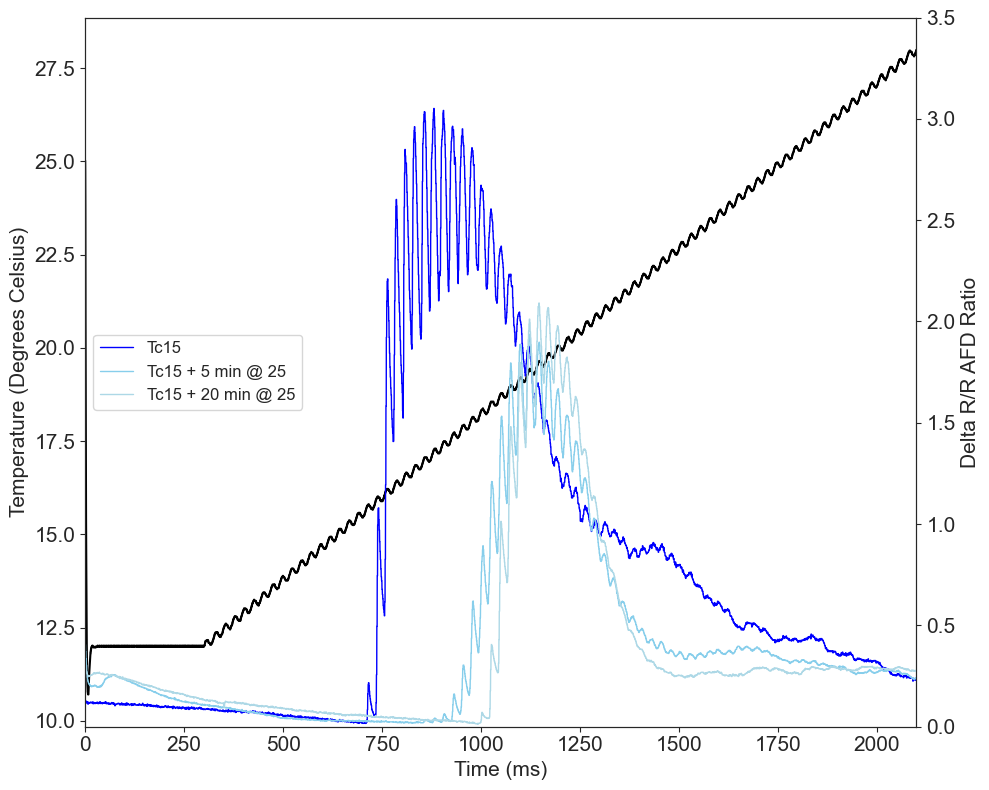

<Figure size 640x480 with 0 Axes>

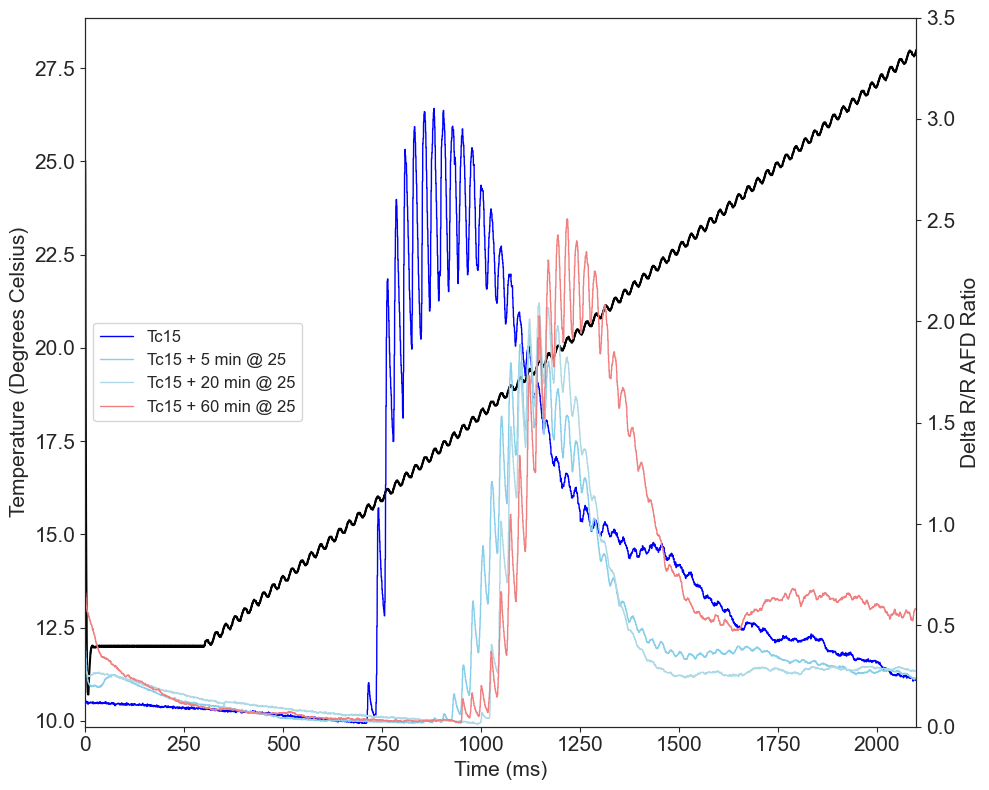

In [28]:
import matplotlib.pyplot as plt

# Define color palette for consistency
colors = {
    'Tc15': 'blue',
    'min5': 'skyblue',      # Lighter blue
    'min20': 'lightblue',   # Much lighter blue
    'min60': 'lightcoral'    # Soft red
}

# --- PLOT 1: Tc15 and early exposure groups ---
plt.clf()
fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(10, 8))

# Temperature Stimulus
ax1.plot(min5_WT_Soma['Time'], min5_WT_Soma['Temp'], 'k', label='Temp Stimulus')
ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize=15)
ax1.set_xlabel('Time (ms)', fontsize=15)
ax1.set_xlim(min(min20_WT_Soma['Time']), max(min20_WT_Soma['Time']))
ax1.tick_params(axis='both', which='major', labelsize=15)

# Calcium Dynamics (AFD Ratio)
ax2 = ax1.twinx()
ax2.plot(Tc15_WT_Soma['Time'], Tc15_WT_Soma['Mean_Delta'], c=colors['Tc15'], lw=1, label='Tc15')
ax2.plot(min5_WT_Soma['Time'], min5_WT_Soma['Mean_Delta'], c=colors['min5'], lw=1, label='Tc15 + 5 min @ 25')
ax2.plot(min20_WT_Soma['Time'], min20_WT_Soma['Mean_Delta'], c=colors['min20'], lw=1, label='Tc15 + 20 min @ 25')

ax2.set_ylabel('Delta R/R AFD Ratio', fontsize=15)
ax2.set_ylim(0, 3.5)
ax2.legend(fontsize=12, loc='center left')
ax2.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()


# --- PLOT 2: All groups including Tc25 ---
plt.clf()
fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(10, 8))

# Temperature Stimulus
ax1.plot(min5_WT_Soma['Time'], min5_WT_Soma['Temp'], 'k', label='Temp Stimulus')
ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize=15)
ax1.set_xlabel('Time (ms)', fontsize=15)
ax1.set_xlim(min(min20_WT_Soma['Time']), max(min20_WT_Soma['Time']))
ax1.tick_params(axis='both', which='major', labelsize=15)

# Calcium Dynamics (AFD Ratio)
ax2 = ax1.twinx()
ax2.plot(Tc15_WT_Soma['Time'], Tc15_WT_Soma['Mean_Delta'], c=colors['Tc15'], lw=1, label='Tc15')
ax2.plot(min5_WT_Soma['Time'], min5_WT_Soma['Mean_Delta'], c=colors['min5'], lw=1, label='Tc15 + 5 min @ 25')
ax2.plot(min20_WT_Soma['Time'], min20_WT_Soma['Mean_Delta'], c=colors['min20'], lw=1, label='Tc15 + 20 min @ 25')
ax2.plot(min60_WT_Soma['Time'], min60_WT_Soma['Mean_Delta'], c=colors['min60'], lw=1, label='Tc15 + 60 min @ 25')

ax2.set_ylabel('Delta R/R AFD Ratio', fontsize=15)
ax2.set_ylim(0, 3.5)
ax2.legend(fontsize=12, loc='center left')
ax2.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()

# Oscillation Analysis: Prominence and Gain Calculation

In [8]:
import numpy as np
from scipy.signal import find_peaks, peak_prominences, peak_widths
import matplotlib.pyplot as plt


def plot_afd_calcium_analysis(
    Time,
    Temp,
    DeltaR,
    minProm=0.4,
    minPeakDist_sec=15,
    deriv_pre_frames=51,
    color='b',
    save=None
):
    """
    Analyze AFD calcium traces and estimate local gain.

    Gain is defined as:

        peak prominence / mean positive temperature derivative

    where the derivative is averaged over the preceding
    `deriv_pre_frames` immediately before each detected peak.

    Parameters
    ----------
    Time : array-like
    Temp : array-like
    DeltaR : array-like
    minProm : float
        Minimum peak prominence.
    minPeakDist_sec : float
        Minimum separation between peaks (seconds).
    deriv_pre_frames : int
        Number of frames preceding each peak used to compute
        mean positive temperature derivative.
    color : str
    save : str or None
    """

    # ------------------------------------------------------------
    # 1. Data preparation
    # ------------------------------------------------------------
    Time = np.asarray(Time, dtype=float)
    Temp = np.asarray(Temp, dtype=float)
    DeltaR = np.asarray(DeltaR, dtype=float)

    y = DeltaR.copy()

    # shift upward if trace contains negative values
    y_min = np.min(y)
    if y_min < 0:
        y = y - y_min

    dt_sec = np.mean(np.diff(Time))
    if dt_sec <= 0:
        raise ValueError("Time array must be increasing.")

    Temp_deriv = np.gradient(Temp, Time)

    minPeakDist_pts = int(np.ceil(minPeakDist_sec / dt_sec))

    # ------------------------------------------------------------
    # 2. Peak detection
    # ------------------------------------------------------------
    locs, properties = find_peaks(
        y,
        prominence=minProm,
        distance=minPeakDist_pts
    )

    pks = y[locs]

    # prominence window for peak detection only
    wlen_points = 601
    if wlen_points % 2 == 0:
        wlen_points += 1

    proms = peak_prominences(y, locs, wlen=wlen_points)[0]
    widths = peak_widths(y, locs, rel_height=0.5)[0]

    # ------------------------------------------------------------
    # 3. Local gain estimate
    # ------------------------------------------------------------
    local_temp_derivs = []
    gains = []

    eps = 1e-6

    for peak_idx, prom in zip(locs, proms):

        left = max(0, peak_idx - deriv_pre_frames)
        right = peak_idx

        local_deriv = Temp_deriv[left:right]

        # positive heating only
        pos_deriv = local_deriv[local_deriv > 0]

        if len(pos_deriv) > 0:
            mean_pos_deriv = np.mean(pos_deriv)
        else:
            mean_pos_deriv = np.nan

        local_temp_derivs.append(mean_pos_deriv)

        if np.isfinite(mean_pos_deriv) and mean_pos_deriv > eps:
            gains.append(prom / mean_pos_deriv)
        else:
            gains.append(np.nan)

    local_temp_derivs = np.asarray(local_temp_derivs)
    gains = np.asarray(gains)

    # ------------------------------------------------------------
    # 4. Plotting
    # ------------------------------------------------------------
    fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
    fig.suptitle('AFD Calcium Gain Analysis', fontsize=16)

    def setup_temp_axis(ax):
        ax.plot(Time, Temp, '-k', linewidth=1.2)
        ax.set_ylabel('Temperature (C)', color='k', fontsize=12)
        ax.tick_params(axis='y', labelcolor='k')
        ax.set_ylim(np.min(Temp), np.max(Temp))
        ax.grid(False)
        ax.spines['right'].set_visible(False)
        return ax.twinx()

    # ------------------------------------------------------------
    # Panel 1: trace and peaks
    # ------------------------------------------------------------
    ax1_twin = setup_temp_axis(axes[0])

    ax1_twin.plot(Time, y, '-', color=color, linewidth=1.2)
    ax1_twin.plot(
        Time[locs],
        pks,
        'o',
        color=color,
        markerfacecolor=color
    )

    ax1_twin.set_ylabel('GCaMP (ΔR/R)', color=color, fontsize=12)
    ax1_twin.tick_params(axis='y', labelcolor=color)
    ax1_twin.set_ylim(0, np.max(y) * 1.1)

    axes[0].set_title('Trace and Peaks')

    # ------------------------------------------------------------
    # Panel 2: peak height
    # ------------------------------------------------------------
    ax2_twin = setup_temp_axis(axes[1])

    markerline, stemlines, baseline = ax2_twin.stem(
        Time[locs],
        pks,
        basefmt=" "
    )

    plt.setp(markerline, color=color)
    plt.setp(stemlines, color=color)

    ax2_twin.set_ylabel('Peak Height (ΔR/R)', color=color, fontsize=12)
    ax2_twin.tick_params(axis='y', labelcolor=color)

    if len(pks) > 0:
        ax2_twin.set_ylim(0, np.max(pks) * 1.2)

    # ------------------------------------------------------------
    # Panel 3: peak prominence
    # ------------------------------------------------------------
    ax3_twin = setup_temp_axis(axes[2])

    markerline, stemlines, baseline = ax3_twin.stem(
        Time[locs],
        proms,
        basefmt=" "
    )

    plt.setp(markerline, color=color)
    plt.setp(stemlines, color=color)

    ax3_twin.set_ylabel('Prominence (ΔR/R)', color=color, fontsize=12)
    ax3_twin.tick_params(axis='y', labelcolor=color)

    if len(proms) > 0:
        ax3_twin.set_ylim(0, np.max(proms) * 1.2)

    # ------------------------------------------------------------
    # Panel 4: gain
    # ------------------------------------------------------------
    ax4_twin = setup_temp_axis(axes[3])

    valid = np.isfinite(gains)

    if np.sum(valid) > 0:
        markerline, stemlines, baseline = ax4_twin.stem(
            Time[locs][valid],
            gains[valid],
            basefmt=" "
        )

        plt.setp(markerline, color=color)
        plt.setp(stemlines, color=color)

        ax4_twin.set_ylim(0, np.nanmax(gains) * 1.2)

    ax4_twin.set_ylabel('Gain (ΔR/R)/(°C/s)', color=color, fontsize=12)
    ax4_twin.tick_params(axis='y', labelcolor=color)

    axes[3].set_xlabel('Time (s)', fontsize=12)

    plt.tight_layout()

    if save is not None:
        plt.savefig(save, dpi=600, bbox_inches='tight')

    plt.show()

    # ------------------------------------------------------------
    # 5. Summary
    # ------------------------------------------------------------
    print("\n--- Analysis Summary ---")

    if len(pks) > 0:
        print(f"Total Peaks Found: {len(pks)}")
        print(f"Mean Peak Height: {np.mean(pks):.3f} ΔR/R")
        print(f"Mean Peak Prominence: {np.mean(proms):.3f} ΔR/R")
        print(f"Mean Peak Width: {np.mean(widths):.2f} points")

        valid_gain = gains[np.isfinite(gains)]

        if len(valid_gain) > 0:
            print(f"Mean Gain: {np.mean(valid_gain):.3f} (ΔR/R)/(°C/s)")
        else:
            print("Mean Gain: could not be estimated")

    else:
        print("No significant peaks found.")

    return {
        'peak_indices': locs,
        'peak_heights': pks,
        'prominences': proms,
        'local_temp_derivs': local_temp_derivs,
        'gains': gains
    }

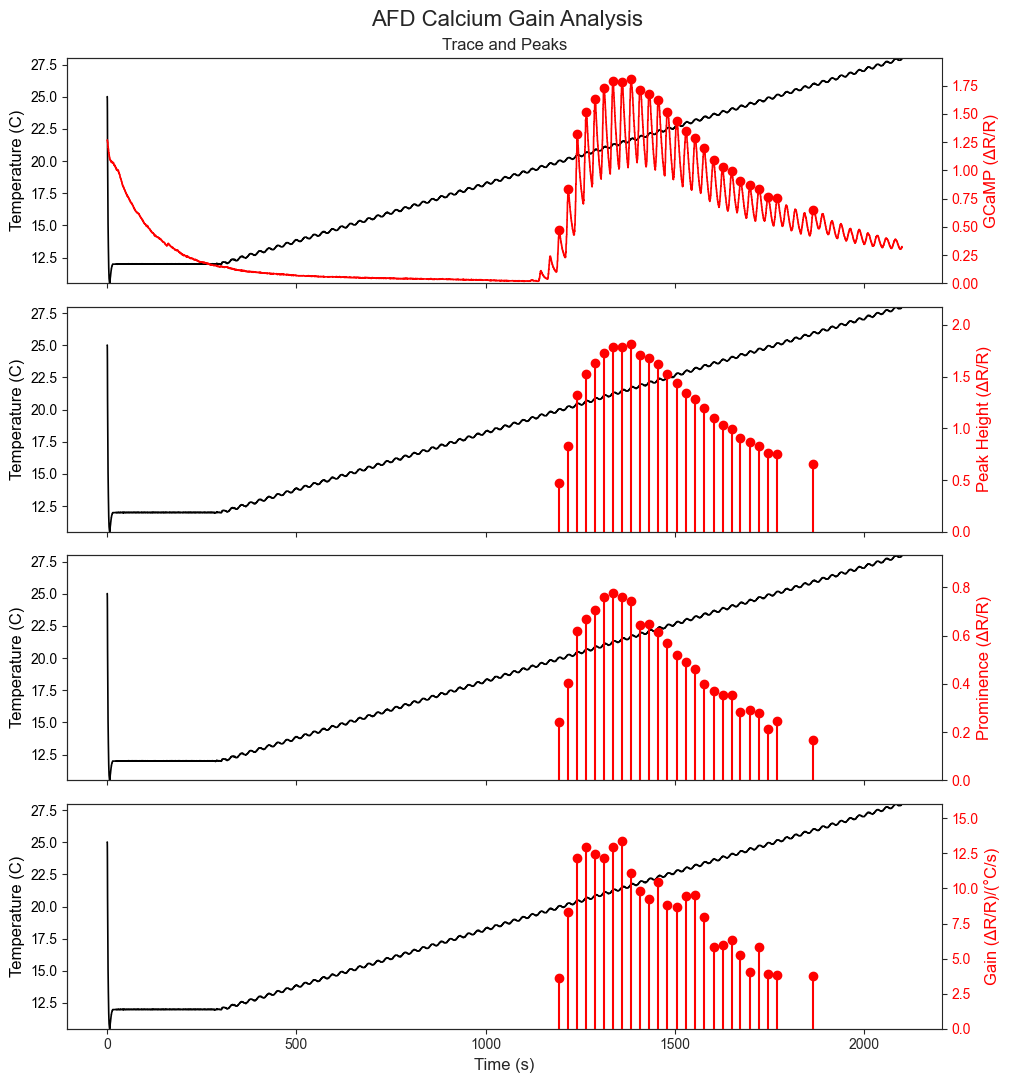


--- Analysis Summary ---
Total Peaks Found: 26
Mean Peak Height: 1.253 ΔR/R
Mean Peak Prominence: 0.484 ΔR/R
Mean Peak Width: 120.58 points
Mean Gain: 8.380 (ΔR/R)/(°C/s)


{'peak_indices': array([11942, 12177, 12417, 12657, 12888, 13117, 13357, 13607, 13838,
        14068, 14318, 14558, 14798, 15048, 15288, 15537, 15767, 16017,
        16257, 16497, 16727, 16982, 17217, 17447, 17697, 18657]),
 'peak_heights': array([0.46802659, 0.83260841, 1.32009232, 1.52098357, 1.62834616,
        1.72789256, 1.78949026, 1.78273511, 1.81165545, 1.7112692 ,
        1.68033812, 1.6195318 , 1.52143224, 1.43923951, 1.34539454,
        1.28686407, 1.19602289, 1.09521184, 1.02767269, 0.99162371,
        0.90688598, 0.86957991, 0.8326701 , 0.76249624, 0.75386364,
        0.65195377]),
 'prominences': array([0.24041102, 0.40476875, 0.61763038, 0.66683428, 0.70562496,
        0.75975326, 0.7776495 , 0.75871236, 0.74347955, 0.6430933 ,
        0.64836815, 0.6163766 , 0.56886796, 0.5204125 , 0.4895423 ,
        0.46227156, 0.39882951, 0.37005176, 0.35486268, 0.35186061,
        0.28280566, 0.29232021, 0.28081063, 0.21063677, 0.24538735,
        0.16898549]),
 'local_temp_derivs':

In [9]:
color=iter(cm.bwr_r(np.linspace(0,1,8)))
dir = 'Peak_Height_Prominence_Analysis/'
Time_Min0 = AFD_Min0['Time']
Temp_Min0 = AFD_Min0['Temp']
DeltaR_Min0 = AFD_Min0['Mean_Delta']
save = None
plot_afd_calcium_analysis(Time_Min0, Temp_Min0, DeltaR_Min0, minProm=0.2, minPeakDist_sec=15, color=next(color), save = save)



In [29]:
import numpy as np
from scipy.signal import find_peaks, peak_prominences, peak_widths
import matplotlib.pyplot as plt


def plot_afd_calcium_analysis(
    Time,
    Temp,
    DeltaR,
    minProm=0.4,
    minPeakDist_sec=15,
    deriv_pre_frames=51,
    color='b',
    save=None,
    time_bounds=None,
    figsize=(3, 10)
):
    """
    Analyze AFD calcium traces and estimate local gain.

    Gain is defined as:

        peak prominence / mean positive temperature derivative

    where the derivative is averaged over the preceding
    `deriv_pre_frames` immediately before each detected peak.

    Parameters
    ----------
    Time : array-like
    Temp : array-like
    DeltaR : array-like
    minProm : float
        Minimum peak prominence.
    minPeakDist_sec : float
        Minimum separation between peaks (seconds).
    deriv_pre_frames : int
        Number of frames preceding each peak used to compute
        mean positive temperature derivative.
    color : str
    save : str or None
    time_bounds : tuple or None
        Time bounds for plotting.
    """

    # ------------------------------------------------------------
    # 1. Data preparation
    # ------------------------------------------------------------
    Time = np.asarray(Time, dtype=float)
    Temp = np.asarray(Temp, dtype=float)
    DeltaR = np.asarray(DeltaR, dtype=float)

    y = DeltaR.copy()

    # shift upward if trace contains negative values
    y_min = np.min(y)
    if y_min < 0:
        y = y - y_min

    dt_sec = np.mean(np.diff(Time))
    if dt_sec <= 0:
        raise ValueError("Time array must be increasing.")

    Temp_deriv = np.gradient(Temp, Time)

    minPeakDist_pts = int(np.ceil(minPeakDist_sec / dt_sec))

    # ------------------------------------------------------------
    # 2. Peak detection
    # ------------------------------------------------------------
    locs, properties = find_peaks(
        y,
        prominence=minProm,
        distance=minPeakDist_pts
    )

    pks = y[locs]

    # prominence window for peak detection only
    wlen_points = 601
    if wlen_points % 2 == 0:
        wlen_points += 1

    proms = peak_prominences(y, locs, wlen=wlen_points)[0]
    widths = peak_widths(y, locs, rel_height=0.5)[0]

    # ------------------------------------------------------------
    # 3. Local gain estimate
    # ------------------------------------------------------------
    local_temp_derivs = []
    gains = []

    eps = 1e-6

    for peak_idx, prom in zip(locs, proms):

        left = max(0, peak_idx - deriv_pre_frames)
        right = peak_idx

        local_deriv = Temp_deriv[left:right]

        # positive heating only
        pos_deriv = local_deriv[local_deriv > 0]

        if len(pos_deriv) > 0:
            mean_pos_deriv = np.mean(pos_deriv)
        else:
            mean_pos_deriv = np.nan

        local_temp_derivs.append(mean_pos_deriv)

        if np.isfinite(mean_pos_deriv) and mean_pos_deriv > eps:
            gains.append(prom / mean_pos_deriv)
        else:
            gains.append(np.nan)

    local_temp_derivs = np.asarray(local_temp_derivs)
    gains = np.asarray(gains)

    # ------------------------------------------------------------
    # 4. Plotting
    # ------------------------------------------------------------
    fig, axes = plt.subplots(4, 1, figsize=figsize, sharex=True)
    fig.suptitle('AFD Calcium Gain Analysis', fontsize=16)

    def setup_temp_axis(ax):
        ax.plot(Time, Temp, '-k', linewidth=1.2)
        ax.set_ylabel('Temperature (C)', color='k', fontsize=10)
        ax.tick_params(axis='y', labelcolor='k')
        ax.set_xlim(time_bounds if time_bounds is not None else (np.min(Time), np.max(Time)))
        ax.set_ylim(np.min(Temp), np.max(Temp))
        ax.grid(False)
        ax.spines['right'].set_visible(False)
        return ax.twinx()

    # ------------------------------------------------------------
    # Panel 1: trace and peaks
    # ------------------------------------------------------------
    ax1_twin = setup_temp_axis(axes[0])

    ax1_twin.plot(Time, y, '-', color=color, linewidth=1.2)
    ax1_twin.plot(
        Time[locs],
        pks,
        'o',
        color=color,
        markerfacecolor=color,
        markersize=4
    )

    ax1_twin.set_ylabel('GCaMP (ΔR/R)', color=color, fontsize=10)
    ax1_twin.tick_params(axis='y', labelcolor=color)
    ax1_twin.set_ylim(0, 2.5 * 1.1)
    ax1_twin.set_xlim(time_bounds if time_bounds is not None else (np.min(Time), np.max(Time)))

    axes[0].set_title('Trace and Peaks')

    # ------------------------------------------------------------
    # Panel 2: peak height
    # ------------------------------------------------------------
    ax2_twin = setup_temp_axis(axes[1])

    markerline, stemlines, baseline = ax2_twin.stem(
        Time[locs],
        pks,
        basefmt=" "
    )

    plt.setp(markerline, color=color, markersize=4)
    plt.setp(stemlines, color=color)

    ax2_twin.set_ylabel('Peak Height (ΔR/R)', color=color, fontsize=10)
    ax2_twin.tick_params(axis='y', labelcolor=color)

    if len(pks) > 0:
        ax2_twin.set_ylim(0, np.max(pks) * 1.2)

    # ------------------------------------------------------------
    # Panel 3: peak prominence
    # ------------------------------------------------------------
    ax3_twin = setup_temp_axis(axes[2])

    markerline, stemlines, baseline = ax3_twin.stem(
        Time[locs],
        proms,
        basefmt=" "
    )

    plt.setp(markerline, color=color, markersize=4)
    plt.setp(stemlines, color=color)

    ax3_twin.set_ylabel('Prominence (ΔR/R)', color=color, fontsize=10)
    ax3_twin.tick_params(axis='y', labelcolor=color)

    if len(proms) > 0:
        ax3_twin.set_ylim(0, 0.8 * 1.1)

    # ------------------------------------------------------------
    # Panel 4: gain
    # ------------------------------------------------------------
    ax4_twin = setup_temp_axis(axes[3])

    valid = np.isfinite(gains)

    if np.sum(valid) > 0:
        markerline, stemlines, baseline = ax4_twin.stem(
            Time[locs][valid],
            gains[valid],
            basefmt=" "
        )

        plt.setp(markerline, color=color, markersize=4)
        plt.setp(stemlines, color=color)

        ax4_twin.set_ylim(0, np.nanmax(gains) * 1.2)

    ax4_twin.set_ylabel('Gain (ΔR/R)/(°C/s)', color=color, fontsize=10)
    ax4_twin.tick_params(axis='y', labelcolor=color)

    axes[3].set_xlabel('Time (s)', fontsize=10)

    if len(proms) > 0:
        ax4_twin.set_ylim(0, 15.5 * 1.1)
        
    plt.tight_layout()

    if save is not None:
        plt.savefig(save, dpi=600, bbox_inches='tight')

    plt.show()

    # ------------------------------------------------------------
    # 5. Summary
    # ------------------------------------------------------------
    print("\n--- Analysis Summary ---")

    if len(pks) > 0:
        print(f"Total Peaks Found: {len(pks)}")
        print(f"Mean Peak Height: {np.mean(pks):.3f} ΔR/R")
        print(f"Mean Peak Prominence: {np.mean(proms):.3f} ΔR/R")
        print(f"Mean Peak Width: {np.mean(widths):.2f} points")

        valid_gain = gains[np.isfinite(gains)]

        if len(valid_gain) > 0:
            print(f"Mean Gain: {np.mean(valid_gain):.3f} (ΔR/R)/(°C/s)")
        else:
            print("Mean Gain: could not be estimated")

    else:
        print("No significant peaks found.")

    return {
        'peak_indices': locs,
        'peak_heights': pks,
        'prominences': proms,
        'local_temp_derivs': local_temp_derivs,
        'gains': gains
    }

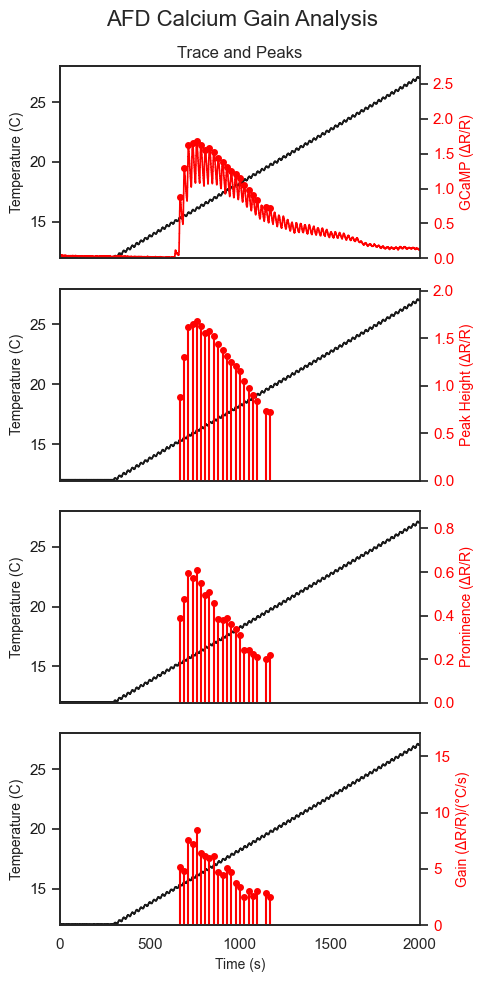


--- Analysis Summary ---
Total Peaks Found: 21
Mean Peak Height: 1.257 ΔR/R
Mean Peak Prominence: 0.389 ΔR/R
Mean Peak Width: 225.56 points
Mean Gain: 4.797 (ΔR/R)/(°C/s)


{'peak_indices': array([ 6688,  6908,  7148,  7378,  7598,  7838,  8068,  8308,  8568,
         8808,  9048,  9288,  9528,  9768, 10018, 10238, 10498, 10718,
        10958, 11448, 11688]),
 'peak_heights': array([0.8760308 , 1.29797877, 1.61681919, 1.65201841, 1.6838967 ,
        1.62437456, 1.55815964, 1.57975075, 1.5258978 , 1.43994187,
        1.37870915, 1.31327985, 1.24903554, 1.21040455, 1.15506989,
        1.04860634, 0.9793774 , 0.90618263, 0.83627104, 0.73158007,
        0.72740192]),
 'prominences': array([0.38843126, 0.47756998, 0.59617935, 0.5742414 , 0.60772781,
        0.54820567, 0.49391222, 0.51063437, 0.45678142, 0.3866073 ,
        0.37800861, 0.38961113, 0.36388179, 0.34003889, 0.31329223,
        0.24249778, 0.24334708, 0.22370568, 0.212501  , 0.20123918,
        0.21804265]),
 'local_temp_derivs': array([0.07512723, 0.09859558, 0.07886273, 0.07939667, 0.07147954,
        0.08492492, 0.08048019, 0.08538771, 0.07429652, 0.08123354,
        0.08546444, 0.07662438, 0.0

In [36]:
color=iter(cm.bwr_r(np.linspace(0,1,8)))
dir = 'Peak_Height_Prominence_Analysis/'
Time_Min240 = AFD_Min240['Time']
Temp_Min240 = AFD_Min240['Temp']
DeltaR_Min240 = AFD_Min240['Mean_Delta']
save = "C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/Peak_Height_Prominence_Analysis/Cut_Peak_Analysis_Min240.svg"
#save = None
#time_bounds = (500, 1200)
time_bounds=(0,2000)
figsize=(5, 10)
deriv_pre_frames = 100
plot_afd_calcium_analysis(Time_Min240, Temp_Min240, DeltaR_Min240, deriv_pre_frames=deriv_pre_frames, minProm=0.2, minPeakDist_sec=15, color=next(color), save = save, time_bounds = time_bounds, figsize=figsize)



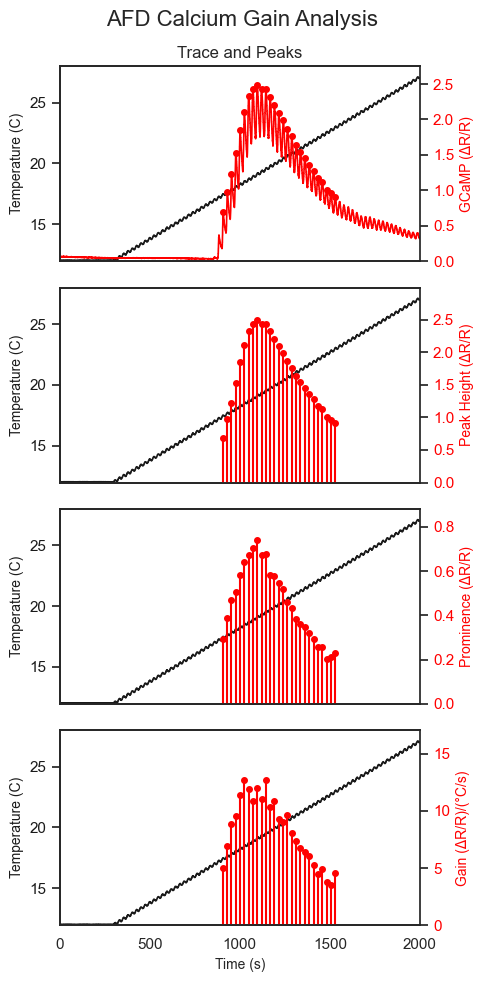


--- Analysis Summary ---
Total Peaks Found: 27
Mean Peak Height: 1.672 ΔR/R
Mean Peak Prominence: 0.456 ΔR/R
Mean Peak Width: 198.74 points
Mean Gain: 8.274 (ΔR/R)/(°C/s)


{'peak_indices': array([ 9069,  9303,  9534,  9784, 10024, 10249, 10489, 10719, 10964,
        11203, 11454, 11694, 11914, 12164, 12414, 12643, 12884, 13123,
        13363, 13613, 13843, 14093, 14334, 14568, 14814, 15054, 15304]),
 'peak_heights': array([0.69047836, 0.98016907, 1.22659965, 1.52641808, 1.84538806,
        2.10911928, 2.32676022, 2.43050602, 2.48986891, 2.43282952,
        2.43504515, 2.31656941, 2.20363095, 2.08628975, 1.99354922,
        1.86852491, 1.76273235, 1.63504997, 1.53417412, 1.44977567,
        1.3606372 , 1.27723196, 1.18049488, 1.12013118, 1.00607949,
        0.95640044, 0.90770111]),
 'prominences': array([0.29484989, 0.38977989, 0.46826469, 0.50732418, 0.58370374,
        0.64044925, 0.67114194, 0.70224993, 0.7393016 , 0.67326778,
        0.67548341, 0.58285289, 0.5797503 , 0.54385434, 0.52057295,
        0.45861824, 0.43450119, 0.38416219, 0.36138874, 0.34794989,
        0.32188882, 0.29136731, 0.25690418, 0.25673573, 0.20120744,
        0.20953815, 0.22

In [37]:
color=iter(cm.bwr_r(np.linspace(0,1,8)))
dir = 'Peak_Height_Prominence_Analysis/'
Time_Min60 = AFD_Min60['Time']
Temp_Min60 = AFD_Min60['Temp']
DeltaR_Min60 = AFD_Min60['Mean_Delta']
save = "C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/Peak_Height_Prominence_Analysis/Cut_Peak_Analysis_Min60.svg"
#save = None
time_bounds = (500, 1600)
time_bounds = (0, 2000)
figsize=(5, 10)
deriv_pre_frames=100
plot_afd_calcium_analysis(Time_Min60, Temp_Min60, DeltaR_Min60, deriv_pre_frames=deriv_pre_frames, minProm=0.2, minPeakDist_sec=15, color=next(color), save = save, time_bounds = time_bounds, figsize=figsize)



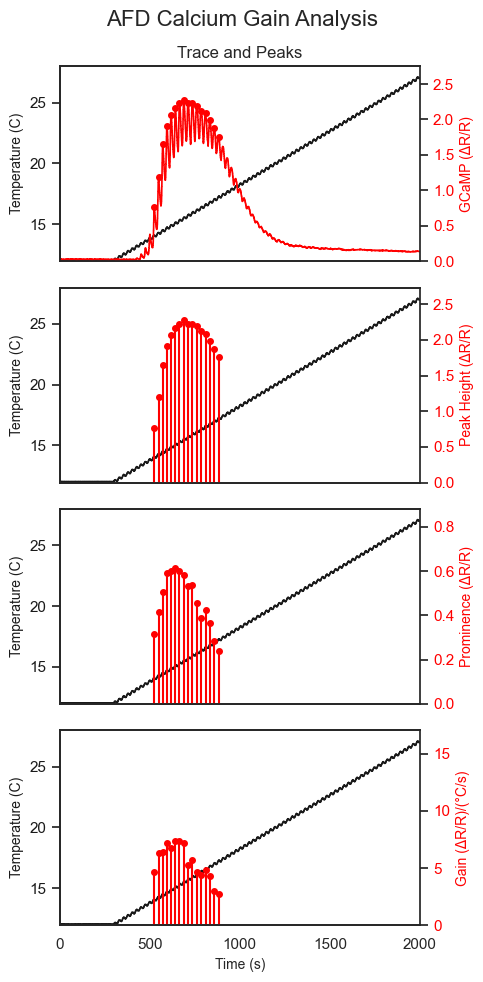


--- Analysis Summary ---
Total Peaks Found: 16
Mean Peak Height: 1.919 ΔR/R
Mean Peak Prominence: 0.465 ΔR/R
Mean Peak Width: 328.90 points
Mean Gain: 5.512 (ΔR/R)/(°C/s)


{'peak_indices': array([5245, 5485, 5715, 5945, 6175, 6415, 6645, 6875, 7115, 7365, 7605,
        7855, 8105, 8334, 8565, 8825]),
 'peak_heights': array([0.76491383, 1.19417303, 1.64747227, 1.90915733, 2.06150799,
        2.15973611, 2.22728501, 2.2756459 , 2.2262993 , 2.22744315,
        2.18784749, 2.11730282, 2.08650545, 1.98718519, 1.87668205,
        1.75964463]),
 'prominences': array([0.31546541, 0.41511189, 0.5047593 , 0.59183516, 0.59826828,
        0.61345242, 0.59837828, 0.5821714 , 0.53282481, 0.53735036,
        0.45776583, 0.38722116, 0.42410542, 0.36430586, 0.28460971,
        0.23892362]),
 'local_temp_derivs': array([0.06787625, 0.06555456, 0.07828553, 0.08209886, 0.08858963,
        0.08339543, 0.08151635, 0.08114263, 0.10031234, 0.09416717,
        0.09843022, 0.08749354, 0.08730121, 0.08518893, 0.09503385,
        0.08825437]),
 'gains': array([4.64765508, 6.33231168, 6.44767049, 7.20881134, 6.75325415,
        7.35594763, 7.3405923 , 7.17466753, 5.31165738, 5.70634

In [38]:
color=iter(cm.bwr_r(np.linspace(0,1,8)))
dir = 'Peak_Height_Prominence_Analysis/'
Time_Tc15 = AFD_Tc15['Time']
Temp_Tc15 = AFD_Tc15['Temp']
DeltaR_Tc15 = AFD_Tc15['Mean_Delta']
save = "C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/Peak_Height_Prominence_Analysis/Cut_Peak_Analysis_Tc15.svg"
#save = None
time_bounds = (400, 1200)
time_bounds = (0, 2000)
figsize=(5, 10)
deriv_pre_frames=100
plot_afd_calcium_analysis(Time_Tc15, Temp_Tc15, DeltaR_Tc15, deriv_pre_frames=deriv_pre_frames, minProm=0.2, minPeakDist_sec=15, color=next(color), save = save, time_bounds = time_bounds, figsize=figsize)



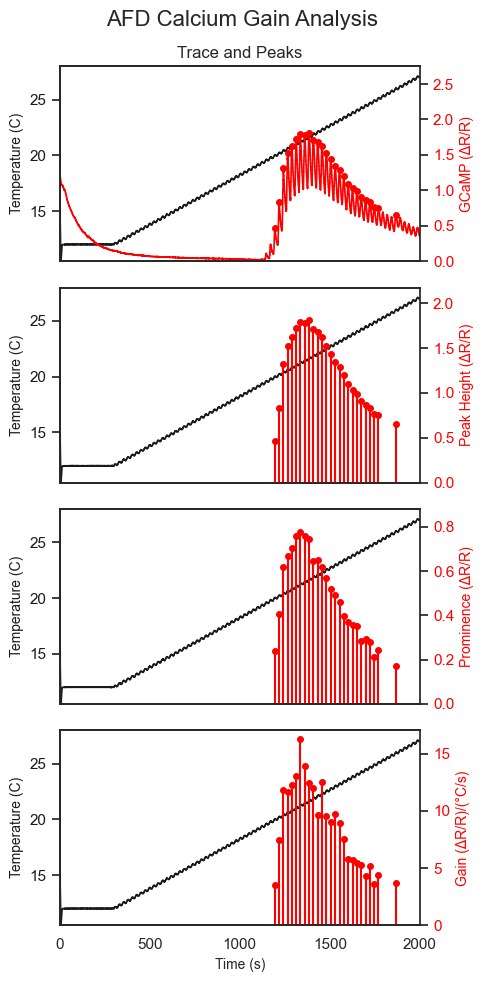


--- Analysis Summary ---
Total Peaks Found: 26
Mean Peak Height: 1.253 ΔR/R
Mean Peak Prominence: 0.484 ΔR/R
Mean Peak Width: 120.58 points
Mean Gain: 8.648 (ΔR/R)/(°C/s)


{'peak_indices': array([11942, 12177, 12417, 12657, 12888, 13117, 13357, 13607, 13838,
        14068, 14318, 14558, 14798, 15048, 15288, 15537, 15767, 16017,
        16257, 16497, 16727, 16982, 17217, 17447, 17697, 18657]),
 'peak_heights': array([0.46802659, 0.83260841, 1.32009232, 1.52098357, 1.62834616,
        1.72789256, 1.78949026, 1.78273511, 1.81165545, 1.7112692 ,
        1.68033812, 1.6195318 , 1.52143224, 1.43923951, 1.34539454,
        1.28686407, 1.19602289, 1.09521184, 1.02767269, 0.99162371,
        0.90688598, 0.86957991, 0.8326701 , 0.76249624, 0.75386364,
        0.65195377]),
 'prominences': array([0.24041102, 0.40476875, 0.61763038, 0.66683428, 0.70562496,
        0.75975326, 0.7776495 , 0.75871236, 0.74347955, 0.6430933 ,
        0.64836815, 0.6163766 , 0.56886796, 0.5204125 , 0.4895423 ,
        0.46227156, 0.39882951, 0.37005176, 0.35486268, 0.35186061,
        0.28280566, 0.29232021, 0.28081063, 0.21063677, 0.24538735,
        0.16898549]),
 'local_temp_derivs':

In [40]:
color=iter(cm.bwr_r(np.linspace(0,1,8)))
dir = 'Peak_Height_Prominence_Analysis/'
Time_Min0 = AFD_Min0['Time']
Temp_Min0 = AFD_Min0['Temp']
DeltaR_Min0 = AFD_Min0['Mean_Delta']
save = "C:/Users/dgmdi/OneDrive - Yale University/Documents/AFD Range of Thermal Perception/Analyses/Peak_Height_Prominence_Analysis/Cut_Peak_Analysis_Min0.svg"
#save = None
time_bounds = (1000, 2000)
time_bounds = (0, 2000)
figsize=(5, 10)
deriv_pre_frames=100
plot_afd_calcium_analysis(Time_Min0, Temp_Min0, DeltaR_Min0, deriv_pre_frames=deriv_pre_frames, minProm=0.2, minPeakDist_sec=15, color=next(color), save = save, time_bounds = time_bounds, figsize=figsize)

